# Исследовательский анализ данных в Python и проверка гипотез.

- Автор: Сереженко Елена
  
Для удобства рекомендую включить `Table of contents`.

Ссылка на дашборд 1-ой части: https://datalens.yandex/13mpaukb3gwel

## 0.1. Цели и задачи проекта

Провести комплексный анализ данных Яндекс Афиши для выявления ключевых факторов изменения пользовательского спроса, оценки динамики активности по категориям событий, площадкам и каналам бронирования, а также сформировать обоснованные выводы и рекомендации для продуктового отдела, в том числе по подготовке к зимнему сезону.

Задачи:
* загрузка данных и знакомство с ними;
* предобработка данных и подготовка их к исследованию:
* исследовательский анализ данных:
* статистический анализ данных;
* общий вывод и рекомендации.

## 0.2. Описание данных

Три таблицы:
- `final_tickets_orders_df.csv` — таблица включает информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных. Путь к файлу: `/datasets/final_tickets_orders_df.csv`:
    * `order_id` — уникальный идентификатор заказа;
    * `user_id` — уникальный идентификатор пользователя;
    * `created_dt_msk` — дата создания заказа (московское время);
    * `created_ts_msk` — дата и время создания заказа (московское время);
    * `event_id` — идентификатор мероприятия из таблицы events;
    * `cinema_circuit` — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет';
    * `age_limit` — возрастное ограничение мероприятия;
    * `currency_code` — валюта оплаты, например rub для российских рублей;
    * `device_type_canonical` — тип устройства, с которого был оформлен заказ;
    * `revenue` — выручка от заказа;
    * `service_name` — название билетного оператора;
    * `tickets_count` — количество купленных билетов;
    * `total` — общая сумма заказа;

- `final_tickets_events_df.csv` — таблица содержит информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия. Путь к файлу: `/datasets/final_tickets_events_df.csv`:
    * `event_id` — уникальный идентификатор мероприятия;
    * `event_name` — название мероприятия. Аналог поля event_name_code из исходной базы данных;
    * `event_type_description` — описание типа мероприятия;
    * `event_type_main` — основной тип мероприятия: театральная постановка, концерт и так далее;
    * `organizers` — организаторы мероприятия;
    * `region_name` — название региона;
    * `city_name` — название города;
    * `venue_id` — уникальный идентификатор площадки;
    * `venue_name` — название площадки;
    * `venue_address` — адрес площадки;

- `final_tickets_tenge_df.csv` — таблица с информацией о курсе тенге к российскому рублю за 2024 год. Путь к файлу: `/datasets/final_tickets_tenge_df.csv`:
    * `nominal` — номинал (100 тенге);
    * `data` — дата;
    * `curs` — курс тенге к рублю;
    * `cdx` — обозначение валюты (kzt).



## 0.3. Содержание проекта

* [1. Загрузка данных и знакомство с ними](#1.-Загрузка-данных-и-знакомство-с-ними)
    * [1.1. Загрузка исторических данных](#1.1.-Загрузка-исторических-данных)
    * [1.2. Знакомство с данными](#1.2.-Знакомство-с-данными)
* [2. Предобработка данных и подготовка их к исследованию](#2.-Предобработка-данных-и-подготовка-их-к-исследованию)
    * [2.1. Проверка данных на пропуски](#2.1.-Проверка-данных-на-пропуски)
    * [2.2. Проверка значений в ключевых столбцах](#2.2.-Проверка-значений-в-ключевых-столбцах)
        * [2.2.1. Для категориальных значений](#2.2.1.-Для-категориальных-значений)
        * [2.2.2. Для количественных значений](#2.2.2.-Для-количественных-значений)
    * [2.3. Проверка данных на явные и неявные дубликаты](#2.3.-Проверка-данных-на-явные-и-неявные-дубликаты)
    * [2.4. Преобразование типов данных](#2.4.-Преобразование-типов-данных)
    * [2.5. Создание новых столбцов для дальнейшего удобства анализа](#2.5.-Создание-новых-столбцов-для-дальнейшего-удобства-анализа)
* [3. Исследовательский анализ данных](#3.-Исследовательский-анализ-данных)
    * [3.1. Анализ распределения заказов по сегментам и их сезонные изменения](#3.1.-Анализ-распределения-заказов-по-сегментам-и-их-сезонные-изменения)
        * [3.1.1. Для кажого месяца](#3.1.1.-Для-кажого-месяца)
        * [3.1.2. Для осеннего и летнего периодов](#3.1.2.-Для-осеннего-и-летнего-периодов)
        * [3.1.3. Изменение выручки с продажи одного билета](#3.1.3.-Изменение-выручки-с-продажи-одного-билета) 
    * [3.2. Осенняя активность пользователей](#3.2.-Осенняя-активность-пользователей)
        * [3.2.1. Анализ динамики изменений по дням](#3.2.1.-Анализ-динамики-изменений-по-дням)
        * [3.2.2. Анализ недельной цикличности](#3.2.2.-Анализ-недельной-цикличности)
    * [3.3. Популярные события и партнёры](#3.3.-Популярные-события-и-партнёры)
        * [3.3.1. Для каждого региона](#3.3.1.-Для-каждого-региона)
        * [3.3.2. Для каждого билетного партнёра](#3.3.2.-Для-каждого-билетного-партнёра)
* [4. Статистический анализ данных](#4.-Статистический-анализ-данных)
    * [4.1. Проверка Гипотезы 1](#4.1.-Проверка-Гипотезы-1)
    * [4.2. Проверка Гипотезы 2](#4.2.-Проверка-Гипотезы-2)
* [5. Общий вывод и рекомендации](#5.-Общий-вывод-и-рекомендации)

### 1. Загрузка данных и знакомство с ними

#### 1.1. Загрузка исторических данных
Импортируем библиотеку `pandas`. 
Дополнительно импортируем библиотеки, необходимые для дальнейшей работы.

Загрузим данные и создадим три датафрейма.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu

In [2]:
final_tickets_orders_df=pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_orders_df.csv')

In [3]:
final_tickets_events_df=pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_events_df.csv')

In [4]:
final_tickets_tenge_df=pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

#### 1.2. Знакомство с данными
Оценим объём данных, их корректность и соответствие описанию, а также предположим, какие шаги необходимо сделать на стадии предобработки данных. 

In [5]:
final_tickets_orders_df.info()
final_tickets_orders_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


Наполнение датафрейма `final_tickets_orders_df` соответствуют описанию. Содержит 290849 строк и 14 столбцов. В столбце `days_since_prev` имеются пропуски, они составляют ~7.5% от общего числа строк. Предположим, что отсутствуют данные, так как не все пользователи совершают повторные покупки. Также можно изменить разрядность у числовых столбцов, столбцы `created_dt_msk` и `created_ts_msk` привести к типу дат. 

In [6]:
final_tickets_events_df.info()
final_tickets_events_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


Наполнение датафрейма `final_tickets_events_df` также соответствуют описанию. Пропусков в таблице не наблюдаем. Можно изменить разрядность в числовых столбцах.

In [7]:
final_tickets_tenge_df.info()
final_tickets_tenge_df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt
...,...,...,...,...
352,2024-12-27,100,19.2705,kzt
353,2024-12-28,100,19.5105,kzt
354,2024-12-29,100,19.4860,kzt
355,2024-12-30,100,19.4860,kzt


Наполнение датафрейма `final_tickets_tenge_df` в рамках описания. Данные описаны за период с 10.01.2024 по 31.12.2024, этот столбец необходимо привести к типу дат, числовые тоже можно изменить по разрядности.

### 2. Предобработка данных и подготовка их к исследованию

Вначале можно объединить данные в один датафрейм, а затем провести общую предобработку.

In [8]:
final_tickets=(
    final_tickets_orders_df
    .merge(final_tickets_events_df, on='event_id',how='left')
    .merge(final_tickets_tenge_df, how='left', left_on='created_dt_msk', right_on='data')
)

final_tickets.info()
final_tickets.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 28 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                290849 non-null  int64  
 1   user_id                 290849 non-null  object 
 2   created_dt_msk          290849 non-null  object 
 3   created_ts_msk          290849 non-null  object 
 4   event_id                290849 non-null  int64  
 5   cinema_circuit          290849 non-null  object 
 6   age_limit               290849 non-null  int64  
 7   currency_code           290849 non-null  object 
 8   device_type_canonical   290849 non-null  object 
 9   revenue                 290849 non-null  float64
 10  service_name            290849 non-null  object 
 11  tickets_count           290849 non-null  int64  
 12  total                   290849 non-null  float64
 13  days_since_prev         268909 non-null  float64
 14  event_name          

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,region_name,city_name,city_id,venue_id,venue_name,venue_address,data,nominal,curs,cdx
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,Каменевский регион,Глиногорск,213.0,3972.0,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-08-20,100,18.6972,kzt
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,...,Каменевский регион,Глиногорск,213.0,2941.0,"Музыкальная школа для детей ""Аккаунт"" Лтд","алл. Шмидта, д. 9 стр. 4",2024-07-23,100,18.3419,kzt
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,...,Каменевский регион,Глиногорск,213.0,4507.0,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6",2024-10-06,100,19.6475,kzt
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,...,Североярская область,Озёрск,2.0,3574.0,"Театр альтернативного искусства ""Ода"" Лимитед","алл. Есенина, д. 243 к. 3/8",2024-07-13,100,18.5010,kzt
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,...,Озернинский край,Родниковецк,240.0,1896.0,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8",2024-10-04,100,19.6648,kzt


Единый датафрейм `final_tickets` содержит 290849 строк и 28 столбцов.

#### 2.1. Проверка данных на пропуски

Выведем отчёт о пропусках в абсолютном и относительном значениях.

In [9]:
gaps=pd.DataFrame({
    'column': final_tickets.columns,
    'dtype': final_tickets.dtypes.values,
    'missing_count': final_tickets.isna().sum().values,
    'missing_percent': (final_tickets.isna().sum()/len(final_tickets)*100).round(2).values
})

display(gaps)

,column,dtype,missing_count,missing_percent
0,order_id,int64,0,0.00
1,user_id,object,0,0.00
2,created_dt_msk,object,0,0.00
3,created_ts_msk,object,0,0.00
4,event_id,int64,0,0.00
5,cinema_circuit,object,0,0.00
6,age_limit,int64,0,0.00
7,currency_code,object,0,0.00
8,device_type_canonical,object,0,0.00
9,revenue,float64,0,0.00


При объединении в столбцах части `final_tickets_events_df` 238 строк с пропусками (видимо по каким-то идентификаторам событий нет информации). Доля таких пропусков крайне мала(менее 1%), их можно удалить.

В столбце `days_since_prev` имеются пропуски, они составляют ~7.5% от общего числа строк. Предположим, что отсутствуют данные, так как не все пользователи совершают повторные покупки. 

In [10]:
final_tickets = final_tickets[final_tickets['event_name'].notna()]
final_tickets.info()

<class 'pandas.core.frame.DataFrame'>
Index: 290611 entries, 0 to 290848
Data columns (total 28 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                290611 non-null  int64  
 1   user_id                 290611 non-null  object 
 2   created_dt_msk          290611 non-null  object 
 3   created_ts_msk          290611 non-null  object 
 4   event_id                290611 non-null  int64  
 5   cinema_circuit          290611 non-null  object 
 6   age_limit               290611 non-null  int64  
 7   currency_code           290611 non-null  object 
 8   device_type_canonical   290611 non-null  object 
 9   revenue                 290611 non-null  float64
 10  service_name            290611 non-null  object 
 11  tickets_count           290611 non-null  int64  
 12  total                   290611 non-null  float64
 13  days_since_prev         268698 non-null  float64
 14  event_name              2

#### 2.2. Проверка значений в ключевых столбцах

##### 2.2.1. Для категориальных значений

Оценим значения в категориальных столбцах на ошибки, задвоения, различное написание одних категорий и так далее.

In [11]:
category=['age_limit', 'cinema_circuit', 'currency_code', 'device_type_canonical', 'service_name', 'event_type_description', 'event_type_main']

for column in category:
    print(f"Виды категорий в столбце '{column}':")
    print(final_tickets[column].unique())
    print()

Виды категорий в столбце 'age_limit':
[16  0 18 12  6]

Виды категорий в столбце 'cinema_circuit':
['нет' 'Другое' 'Киномакс' 'КиноСити' 'Москино' 'ЦентрФильм']

Виды категорий в столбце 'currency_code':
['rub' 'kzt']

Виды категорий в столбце 'device_type_canonical':
['mobile' 'desktop']

Виды категорий в столбце 'service_name':
['Край билетов' 'Мой билет' 'За билетом!' 'Лови билет!'
 'Билеты без проблем' 'Облачко' 'Лучшие билеты' 'Прачечная' 'Быстробилет'
 'Дом культуры' 'Весь в билетах' 'Билеты в руки' 'Тебе билет!'
 'Show_ticket' 'Городской дом культуры' 'Яблоко' 'Билет по телефону'
 'Выступления.ру' 'Росбилет' 'Шоу начинается!' 'Мир касс' 'Восьмёрка'
 'Телебилет' 'Crazy ticket!' 'Реестр' 'Быстрый кассир' 'КарандашРУ'
 'Радио ticket' 'Дырокол' 'Вперёд!' 'Кино билет' 'Цвет и билет' 'Зе Бест!'
 'Тех билет' 'Лимоны' 'Билеты в интернете']

Виды категорий в столбце 'event_type_description':
['спектакль' 'событие' 'цирковое шоу' 'выставка' 'шоу' 'концерт' 'спорт'
 'мюзикл' 'фестиваль' 'ё

В выведенных столбцах ошибок не наблюдаем.

##### 2.2.2. Для количественных значений

Для анализа данных важными показателями являются выручка с заказа `revenue` и количество билетов в заказе `tickets_count`. Посмотрим на распределение и наличие выбросов.

In [12]:
rub_final_tickets=final_tickets[final_tickets['currency_code']=='rub']
kzt_final_tickets=final_tickets[final_tickets['currency_code']=='kzt']

In [13]:
rub_count=rub_final_tickets[['revenue', 'tickets_count']].describe()
kzt_count=kzt_final_tickets[['revenue', 'tickets_count']].describe()

print('Ключевые показатели для рубля (rub):')
display(rub_count)

print('Ключевые показатели для тенге (kzt):')
display(kzt_count)

Ключевые показатели для рубля (rub):


,revenue,tickets_count
count,285542.000000,285542.000000
mean,548.013929,2.754159
std,871.750181,1.171575
min,-90.760000,1.000000
25%,114.170000,2.000000
50%,346.630000,3.000000
75%,793.320000,4.000000
max,81174.540000,57.000000


Ключевые показатели для тенге (kzt):


,revenue,tickets_count
count,5069.000000,5069.000000
mean,4995.206767,2.762872
std,4916.752776,1.115558
min,0.000000,1.000000
25%,518.100000,2.000000
50%,3698.830000,3.000000
75%,7397.660000,4.000000
max,26425.860000,6.000000


Создадим график и ящик с усами распределения выручки.

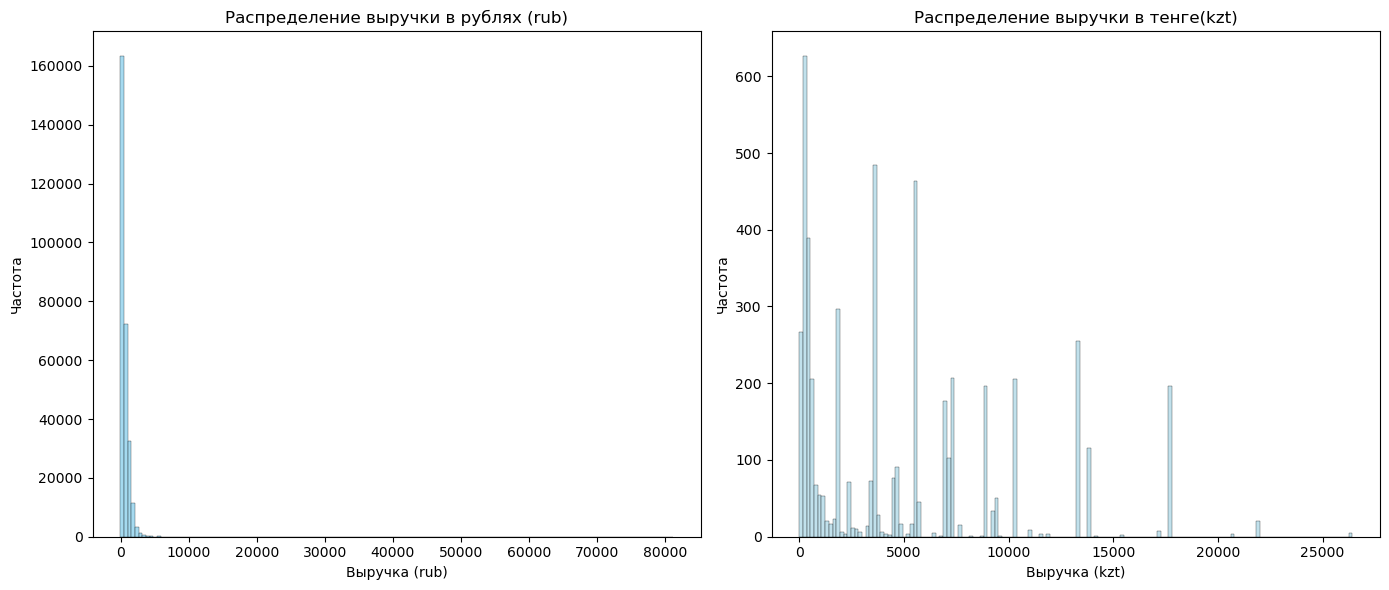

In [14]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(rub_final_tickets['revenue'], color='skyblue', bins=150)
plt.title('Распределение выручки в рублях (rub)')
plt.xlabel('Выручка (rub)')
plt.ylabel('Частота')

plt.subplot(1, 2, 2)
sns.histplot(kzt_final_tickets['revenue'], color='lightblue', bins=150)
plt.title('Распределение выручки в тенге(kzt)')
plt.xlabel('Выручка (kzt)')
plt.ylabel('Частота')

plt.tight_layout()
plt.show()

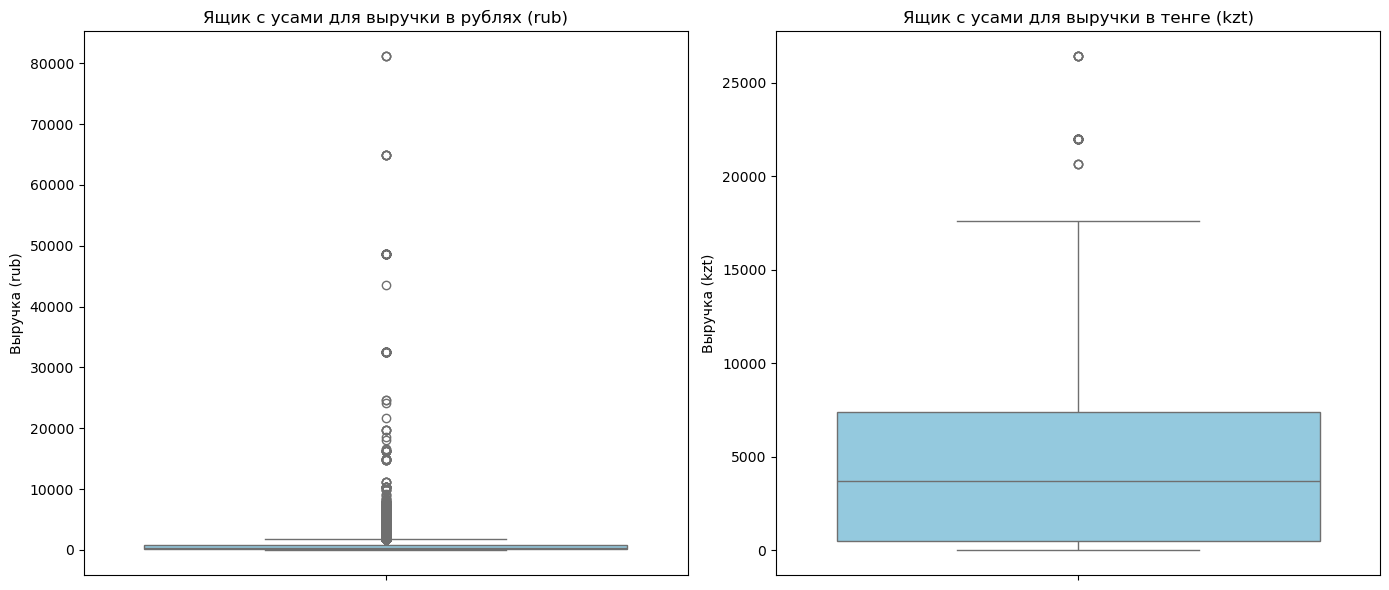

In [15]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=rub_final_tickets['revenue'], color='skyblue')
plt.title('Ящик с усами для выручки в рублях (rub)')
plt.ylabel('Выручка (rub)')

plt.subplot(1, 2, 2)
sns.boxplot(y=kzt_final_tickets['revenue'], color='skyblue')
plt.title('Ящик с усами для выручки в тенге (kzt)')
plt.ylabel('Выручка (kzt)')

plt.tight_layout()
plt.show()

Рублёвые данные (rub):
* Выручка от −90,76 руб. до 81 174,54 руб.:
    - минус — ошибка/возврат, требует удаления;
    - максимум — вероятный выброс.
* Количество билетов от 1 до 57:
    - минимум — норма;
    - максимум может соответствовать крупному заказу.

Данные в тенге (kzt):
* Выручка от 0 тенге до 26 425,86 тенге:
    - ноль допустим (возврат/акция);
    - максимум высок.
* Количество билетов от 1 до 6:
    - оба значения в пределах нормы, корректировки не требуются.

Необходимо удалить записи с отрицательной выручкой, нулевые значения оставим, они в целом допустимы. Для статистической чистоты ограничимся 99 процентилем.

По количеству билетов не будем вносить изменений для этих двух валют — экстремальные значения могут быть реальными заказами.

In [16]:
def apply_percentile_filter(df, revenue_col='revenue', percentile=0.99):

    df_positive=df[df[revenue_col]>=0].copy()

    upper_bound=df_positive[revenue_col].quantile(percentile)

    df_filtered=df_positive[df_positive[revenue_col]<=upper_bound]


    return df_filtered, upper_bound

final_tickets=final_tickets[
    (final_tickets['currency_code']!='rub') |
    (final_tickets['revenue']>=0)
]

rub_data=final_tickets[final_tickets['currency_code']=='rub']
kzt_data=final_tickets[final_tickets['currency_code']=='kzt']

rub_clean, rub_99th=apply_percentile_filter(rub_data, 'revenue', 0.99)
kzt_clean, kzt_99th=apply_percentile_filter(kzt_data, 'revenue', 0.99)

final_tickets=pd.concat([rub_clean, kzt_clean])

print("Статистика очистки данных по 99‑му процентилю:")
print(f"Рублёвые данные: исходно {len(rub_data)} записей, после очистки {len(rub_clean)} записей")
print(f"Граница 99‑го процентиля для RUB: {rub_99th:,.2f} руб.")
print(f"Тенге данные: исходно {len(kzt_data)} записей, после очистки {len(kzt_clean)} записей")
print(f"Граница 99‑го процентиля для KZT: {kzt_99th:,.2f} тенге")
print(f"Итого в final_tickets: {len(final_tickets)} записей")

Статистика очистки данных по 99‑му процентилю:
Рублёвые данные: исходно 285161 записей, после очистки 282361 записей
Граница 99‑го процентиля для RUB: 2,570.80 руб.
Тенге данные: исходно 5069 записей, после очистки 5040 записей
Граница 99‑го процентиля для KZT: 17,617.24 тенге
Итого в final_tickets: 287401 записей


Посмотрим на ключевые показатели после чистки данных.

In [17]:
rub_final_tickets_clean=final_tickets[final_tickets['currency_code']=='rub']
kzt_final_tickets_clean=final_tickets[final_tickets['currency_code']=='kzt']

In [18]:
rub_count=rub_final_tickets_clean[['revenue', 'tickets_count']].describe()
kzt_count=kzt_final_tickets_clean[['revenue', 'tickets_count']].describe()

print('Ключевые показатели для рубля (rub):')
display(rub_count)

print('Ключевые показатели для тенге (kzt):')
display(kzt_count)

Ключевые показатели для рубля (rub):


,revenue,tickets_count
count,282361.000000,282361.000000
mean,511.501020,2.740913
std,500.914811,1.163546
min,0.000000,1.000000
25%,113.020000,2.000000
50%,341.710000,3.000000
75%,782.410000,3.000000
max,2570.800000,57.000000


Ключевые показатели для тенге (kzt):


,revenue,tickets_count
count,5040.000000,5040.000000
mean,4893.669063,2.748413
std,4742.680176,1.101784
min,0.000000,1.000000
25%,515.350000,2.000000
50%,3698.830000,3.000000
75%,7397.660000,3.000000
max,17617.240000,6.000000


Устранены аномалии, исчезли экстремально высокие значения выручки, искажавшие общую картину. Распределение выручки теперь лучше отражает типичные операции.

Разберём ещё и значения в столбце `total`.

In [19]:
rub_total=rub_final_tickets_clean['total'].describe()
kzt_total=kzt_final_tickets_clean['total'].describe()

print('Ключевые показатели по общей сумме заказа (total) в рублях (rub):')
display(rub_total)

print('Ключевые показатели по общей сумме заказа (total) для тенге (kzt):')
display(kzt_total)

Ключевые показатели по общей сумме заказа (total) в рублях (rub):


count    282361.000000
mean       6022.274707
std        5137.421342
min        -184.170000
25%        2111.730000
50%        4607.290000
75%        8648.130000
max       68049.590000
Name: total, dtype: float64

Ключевые показатели по общей сумме заказа (total) для тенге (kzt):


count      5040.000000
mean      73990.099762
std       66180.846177
min           0.000000
25%        9329.050000
50%       61647.160000
75%      114868.830000
max      287172.100000
Name: total, dtype: float64

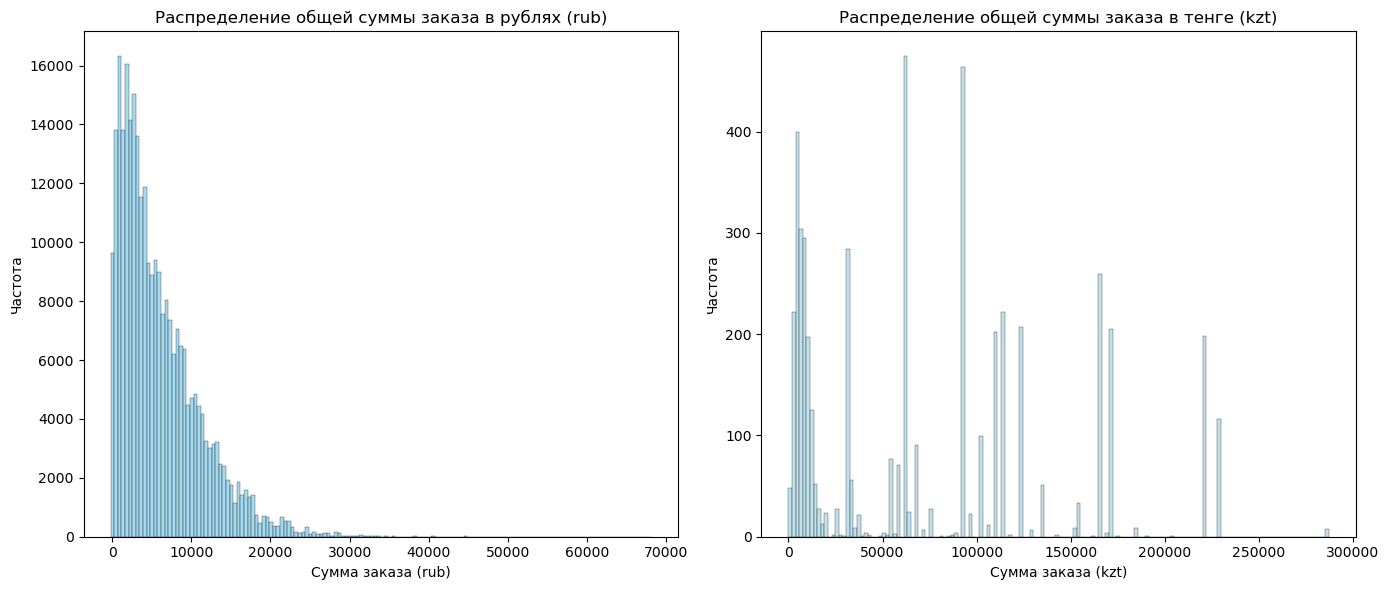

In [20]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(rub_final_tickets_clean['total'], color='skyblue', bins=150)
plt.title('Распределение общей суммы заказа в рублях (rub)')
plt.xlabel('Сумма заказа (rub)')
plt.ylabel('Частота')

plt.subplot(1, 2, 2)
sns.histplot(kzt_final_tickets_clean['total'], color='lightblue', bins=150)
plt.title('Распределение общей суммы заказа в тенге (kzt)')
plt.xlabel('Сумма заказа (kzt)')
plt.ylabel('Частота')


plt.tight_layout()
plt.show()

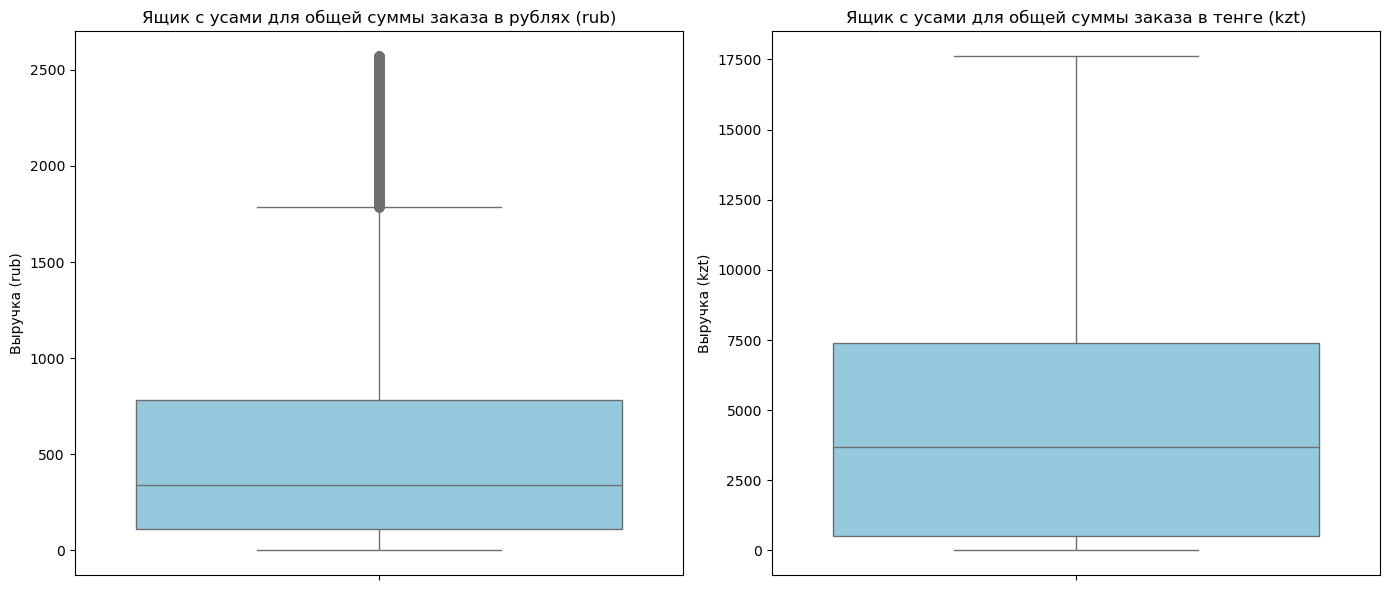

In [21]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=rub_final_tickets_clean['revenue'], color='skyblue')
plt.title('Ящик с усами для общей суммы заказа в рублях (rub)')
plt.ylabel('Выручка (rub)')

plt.subplot(1, 2, 2)
sns.boxplot(y=kzt_final_tickets_clean['revenue'], color='skyblue')
plt.title('Ящик с усами для общей суммы заказа в тенге (kzt)')
plt.ylabel('Выручка (kzt)')

plt.tight_layout()
plt.show()

По рублёвым заказам (rub):
* средний чек — 6 022 руб., но половина заказов дешевле 4 607 руб. (медиана ниже среднего) — значит, на среднее влияют крупные заказы;
* разброс сумм очень большой: стандартное отклонение почти равно среднему (5 137 руб.);
* крупные заказы до 68 050 руб.;
* обнаружены ошибки: есть заказы с отрицательной суммой (−184 руб.) — это некорректно для итоговой суммы.

По заказам в тенге (kzt):
* средний чек — 73 990 тенге, половина заказов дешевле 61 647 тенге (медиана заметно ниже среднего);
* максимальная сумма — 287 172 тенге: не выглядит аномально;
* встречаются нулевые суммы — это допустимо (например, промоакции, возвраты или тестовые заказы).

Можно удалить отрицательные значения total<0 — они точно ошибочные.

In [22]:
final_tickets=final_tickets[
    (final_tickets['currency_code']!='rub') |
    (final_tickets['total']>=0)
    ]

print(f"Итого в final_tickets: {len(final_tickets)} записей")

Итого в final_tickets: 287399 записей


Проверим после удаления статистические значения.

In [23]:
rub_final_tickets_clean_two=final_tickets[final_tickets['currency_code']=='rub']
kzt_final_tickets_clean_two=final_tickets[final_tickets['currency_code']=='kzt']

In [24]:
rub_total=rub_final_tickets_clean_two['total'].describe()
kzt_total=kzt_final_tickets_clean_two['total'].describe()

print('Ключевые показатели по общей сумме заказа (total) в рублях (rub):')
display(rub_total)

print('Ключевые показатели по общей сумме заказа (total) для тенге (kzt):')
display(kzt_total)

Ключевые показатели по общей сумме заказа (total) в рублях (rub):


count    282359.000000
mean       6022.318451
std        5137.413243
min           0.000000
25%        2111.920000
50%        4607.290000
75%        8648.130000
max       68049.590000
Name: total, dtype: float64

Ключевые показатели по общей сумме заказа (total) для тенге (kzt):


count      5040.000000
mean      73990.099762
std       66180.846177
min           0.000000
25%        9329.050000
50%       61647.160000
75%      114868.830000
max      287172.100000
Name: total, dtype: float64

Устранены аномалии.

#### 2.3. Проверка данных на явные и неявные дубликаты

Для начала рассмотрим наличие явных дубликатов.

In [25]:
final_tickets.duplicated().sum()

np.int64(0)

In [26]:
final_tickets.duplicated(subset=['order_id']).sum()

np.int64(0)

Первичный поиск явных дубликатов не выявил таковых. Проведём проверку по неявным дубликатам по определённым столбцам.

In [27]:
duplicates_mask=final_tickets.duplicated(
    subset=['user_id', 'event_id', 'created_ts_msk',  'created_dt_msk', 'revenue', 'total', 'service_name', 'city_id', 'tickets_count'],
    keep=False
)
duplicates=final_tickets[duplicates_mask].copy()

duplicates

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,region_name,city_name,city_id,venue_id,venue_name,venue_address,data,nominal,curs,cdx
11777,1123983,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,...,Светополянский округ,Глиноград,54.0,4443.0,"Центр культурного наследия ""Объединение"" и пар...","бул. Карбышева, д. 50",2024-08-13,100,18.8553,kzt
11778,1123867,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,...,Светополянский округ,Глиноград,54.0,4443.0,"Центр культурного наследия ""Объединение"" и пар...","бул. Карбышева, д. 50",2024-08-13,100,18.8553,kzt
12696,5593202,08199117318954f,2024-07-31,2024-07-31 11:52:06,553623,нет,18,rub,mobile,0.00,...,Каменевский регион,Глиногорск,213.0,3474.0,"Креативное пространство ""Вдох"" Лимитед","бул. Пригородный, д. 7/1",2024-07-31,100,18.2404,kzt
12697,5592970,08199117318954f,2024-07-31,2024-07-31 11:52:06,553623,нет,18,rub,desktop,0.00,...,Каменевский регион,Глиногорск,213.0,3474.0,"Креативное пространство ""Вдох"" Лимитед","бул. Пригородный, д. 7/1",2024-07-31,100,18.2404,kzt
26894,1930705,0dc525d7bacbb0d,2024-07-31,2024-07-31 13:26:11,393430,нет,18,rub,desktop,1556.05,...,Каменевский регион,Глиногорск,213.0,2704.0,"Летний фестиваль ""Симфония"" Лтд","бул. Боровой, д. 8/1 стр. 43",2024-07-31,100,18.2404,kzt
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
285618,8548070,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:50,489843,нет,18,rub,desktop,989.57,...,Каменевский регион,Глиногорск,213.0,4017.0,"Студия анимации ""Точка"" Инкорпорэйтед","алл. Тамбовская, д. 7 к. 827",2024-06-19,100,19.2165,kzt
285619,8548099,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:56,489843,нет,18,rub,desktop,989.57,...,Каменевский регион,Глиногорск,213.0,4017.0,"Студия анимации ""Точка"" Инкорпорэйтед","алл. Тамбовская, д. 7 к. 827",2024-06-19,100,19.2165,kzt
285622,8547867,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:56,489843,нет,18,rub,desktop,1319.43,...,Каменевский регион,Глиногорск,213.0,4017.0,"Студия анимации ""Точка"" Инкорпорэйтед","алл. Тамбовская, д. 7 к. 827",2024-06-19,100,19.2165,kzt
209252,3320153,ae8e3d5af3036a6,2024-07-30,2024-07-30 11:20:46,533803,нет,16,kzt,mobile,1849.41,...,Шанырский регион,Широковка,162.0,3407.0,"Арт-кафе ""Речка"" Лимитед","алл. Путейская, д. 548 стр. 7",2024-07-30,100,18.2287,kzt


83 дубликата: сохраняем по одной записи для каждого бронирования.

In [28]:
final_tickets_clean = final_tickets.drop_duplicates(
    subset=['user_id', 'event_id', 'created_ts_msk', 'created_dt_msk', 'revenue', 'total', 'service_name', 'city_id', 'tickets_count'],
    keep='first',
    ignore_index=False
)

final_tickets_clean.info()
final_tickets_clean

<class 'pandas.core.frame.DataFrame'>
Index: 287356 entries, 0 to 290727
Data columns (total 28 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                287356 non-null  int64  
 1   user_id                 287356 non-null  object 
 2   created_dt_msk          287356 non-null  object 
 3   created_ts_msk          287356 non-null  object 
 4   event_id                287356 non-null  int64  
 5   cinema_circuit          287356 non-null  object 
 6   age_limit               287356 non-null  int64  
 7   currency_code           287356 non-null  object 
 8   device_type_canonical   287356 non-null  object 
 9   revenue                 287356 non-null  float64
 10  service_name            287356 non-null  object 
 11  tickets_count           287356 non-null  int64  
 12  total                   287356 non-null  float64
 13  days_since_prev         265680 non-null  float64
 14  event_name              2

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,region_name,city_name,city_id,venue_id,venue_name,venue_address,data,nominal,curs,cdx
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,Каменевский регион,Глиногорск,213.0,3972.0,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-08-20,100,18.6972,kzt
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,...,Каменевский регион,Глиногорск,213.0,2941.0,"Музыкальная школа для детей ""Аккаунт"" Лтд","алл. Шмидта, д. 9 стр. 4",2024-07-23,100,18.3419,kzt
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,...,Каменевский регион,Глиногорск,213.0,4507.0,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6",2024-10-06,100,19.6475,kzt
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,...,Североярская область,Озёрск,2.0,3574.0,"Театр альтернативного искусства ""Ода"" Лимитед","алл. Есенина, д. 243 к. 3/8",2024-07-13,100,18.5010,kzt
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,...,Озернинский край,Родниковецк,240.0,1896.0,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8",2024-10-04,100,19.6648,kzt
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290722,6862648,ffc24188a1d58f2,2024-07-11,2024-07-11 12:39:48,538828,нет,12,kzt,mobile,4735.52,...,Верхоречная область,Серебрянка,163.0,4348.0,"Мастерская живого действия ""Юность"" Лтд","наб. Осенняя, д. 376",2024-07-11,100,18.2738,kzt
290723,6763294,ffc24188a1d58f2,2024-09-05,2024-09-05 12:07:00,538828,нет,12,kzt,mobile,4735.52,...,Верхоречная область,Серебрянка,163.0,4348.0,"Мастерская живого действия ""Юность"" Лтд","наб. Осенняя, д. 376",2024-09-05,100,18.4217,kzt
290724,3984021,ffc24188a1d58f2,2024-09-06,2024-09-06 19:20:03,533803,нет,16,kzt,mobile,1849.41,...,Шанырский регион,Широковка,162.0,3407.0,"Арт-кафе ""Речка"" Лимитед","алл. Путейская, д. 548 стр. 7",2024-09-06,100,18.5504,kzt
290726,8493869,ffc4133fbba20f4,2024-06-21,2024-06-21 14:04:34,533803,нет,16,kzt,mobile,3698.83,...,Шанырский регион,Широковка,162.0,3407.0,"Арт-кафе ""Речка"" Лимитед","алл. Путейская, д. 548 стр. 7",2024-06-21,100,18.5791,kzt


Почистили общий датасет от дубликатов.

#### 2.4. Преобразование типов данных

Изменим разрядность для числовых столбцов, `created_dt_msk`, `created_ts_msk`, `data` приведём к типу `data`.

In [29]:
final_tickets = final_tickets.copy()

def downcast_numeric(final_tickets):
    for col in final_tickets.columns:
        col_type=final_tickets[col].dtype

        if col_type=='int64':
            final_tickets[col]=pd.to_numeric(final_tickets[col], downcast='integer')
        elif col_type=='float64':
            final_tickets[col]=pd.to_numeric(final_tickets[col], downcast='float')
    return final_tickets

final_tickets=downcast_numeric(final_tickets_clean)

for col in ['created_dt_msk', 'created_ts_msk', 'data']:
    final_tickets[col]=pd.to_datetime(final_tickets[col], errors='coerce')

final_tickets.info()

<class 'pandas.core.frame.DataFrame'>
Index: 287356 entries, 0 to 290727
Data columns (total 28 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                287356 non-null  int32         
 1   user_id                 287356 non-null  object        
 2   created_dt_msk          287356 non-null  datetime64[ns]
 3   created_ts_msk          287356 non-null  datetime64[ns]
 4   event_id                287356 non-null  int32         
 5   cinema_circuit          287356 non-null  object        
 6   age_limit               287356 non-null  int8          
 7   currency_code           287356 non-null  object        
 8   device_type_canonical   287356 non-null  object        
 9   revenue                 287356 non-null  float32       
 10  service_name            287356 non-null  object        
 11  tickets_count           287356 non-null  int8          
 12  total                   287356 non-

#### 2.5. Создание новых столбцов для дальнейшего удобства анализа

`revenue_rub` — приведём выручку с заказа к единой валюте — российскому рублю.

In [30]:
def revenue_rub_kzt(row):
    revenue=row['revenue']
    currency_code=row['currency_code'].lower()

    if currency_code=='rub':
        return revenue
    elif currency_code=='kzt':
        return (revenue*row['curs'])/row['nominal']
    else:
        return None

final_tickets['revenue_rub']=final_tickets.apply(revenue_rub_kzt, axis=1)
final_tickets[['revenue', 'currency_code', 'nominal', 'curs', 'revenue_rub']].tail()

,revenue,currency_code,nominal,curs,revenue_rub
290722,4735.520020,kzt,100,18.2738,865.359452
290723,4735.520020,kzt,100,18.4217,872.363269
290724,1849.410034,kzt,100,18.5504,343.072955
290726,3698.830078,kzt,100,18.5791,687.209326
290727,3698.830078,kzt,100,18.5791,687.209326


`one_ticket_revenue_rub` — выручка с продажи одного билета на мероприятие.

In [31]:
final_tickets['one_ticket_revenue_rub']=final_tickets['revenue_rub']/final_tickets['tickets_count']
final_tickets[['revenue', 'currency_code', 'revenue_rub', 'tickets_count','one_ticket_revenue_rub' ]].head()

,revenue,currency_code,revenue_rub,tickets_count,one_ticket_revenue_rub
0,1521.939941,rub,1521.939941,4,380.484985
1,289.450012,rub,289.450012,2,144.725006
2,1258.569946,rub,1258.569946,4,314.642487
3,8.490000,rub,8.490000,2,4.245000
4,1390.410034,rub,1390.410034,3,463.470011


`month` — месяц оформления заказа.

In [32]:
final_tickets['month']=final_tickets['created_dt_msk'].dt.month
final_tickets[['created_dt_msk', 'month']].head()

,created_dt_msk,month
0,2024-08-20,8
1,2024-07-23,7
2,2024-10-06,10
3,2024-07-13,7
4,2024-10-04,10


`season` — столбец с информацией о сезонности, включая такие категории, как: 'лето', 'осень', 'зима', 'весна'.

In [33]:
def seasons(date):
    month = date.month
    if month in [12, 1, 2]:
        return 'зима'
    elif month in [3, 4, 5]:
        return 'весна'
    elif month in [6, 7, 8]:
        return 'лето'
    elif month in [9, 10, 11]:
        return 'осень'

final_tickets['season'] = final_tickets['created_dt_msk'].apply(seasons)
final_tickets[['created_dt_msk', 'month', 'season']].head()

,created_dt_msk,month,season
0,2024-08-20,8,лето
1,2024-07-23,7,лето
2,2024-10-06,10,осень
3,2024-07-13,7,лето
4,2024-10-04,10,осень


In [34]:
final_tickets.info()

<class 'pandas.core.frame.DataFrame'>
Index: 287356 entries, 0 to 290727
Data columns (total 32 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                287356 non-null  int32         
 1   user_id                 287356 non-null  object        
 2   created_dt_msk          287356 non-null  datetime64[ns]
 3   created_ts_msk          287356 non-null  datetime64[ns]
 4   event_id                287356 non-null  int32         
 5   cinema_circuit          287356 non-null  object        
 6   age_limit               287356 non-null  int8          
 7   currency_code           287356 non-null  object        
 8   device_type_canonical   287356 non-null  object        
 9   revenue                 287356 non-null  float32       
 10  service_name            287356 non-null  object        
 11  tickets_count           287356 non-null  int8          
 12  total                   287356 non-

<b> Итоги предобработки данных:</b>

Загружено 3 датасета (final_tickets_orders_df, final_tickets_orders_events_df, final_tickets_tenge_df), все объединены в один датафрейм.

Преобразования:
- даты переведены в `datetime`;
- добавлены столбцы `revenue_rub`, `one_ticket_revenue_rub`, `month`, `season`.

Очистка:
- удалены записи без событий (0.08%);
- убраны отрицательные значения в `revenue`, `total`, ограничены выбросы (99‑й процентиль);
- обработаны пропуски (но оставлены пропуски `days_since_prev` для анализа первых заказов).

Оптимизация:
- снизили разрядность в числовых столбцах.

Дубликаты:
- найдено 83 строки с дубликатами;
- удалено 3 493 строки.

Итоговый размер: 287 356 строки (после удаления утерян 1.2% данных).

### 3. Исследовательский анализ данных

#### 3.1. Анализ распределения заказов по сегментам и их сезонные изменения

Анализ дашборда показал, что в данных наблюдается сезонность — осенью количество заказов увеличивается. На стадии исследовательского анализа изучим изменение пользовательской активности или пользовательского интереса в связи с сезонностью. Проанализируем динамику по таким разрезам:
- тип мероприятия `event_type_main`;
- тип устройства `device_type_canonical`;
- категория мероприятий по возрастному рейтингу `age_limit`.

##### 3.1.1. Для кажого месяца

Сначала для каждого месяца найдём количество заказов, отразим в графиках данную информацию. Проверим, фиксируется ли увеличение заказов от июня к ноябрю 2024 года.

In [35]:
group_month=final_tickets.groupby('month')['order_id'].count().reset_index()
group_month

,month,order_id
0,6,34056
1,7,40358
2,8,44529
3,9,69262
4,10,99151


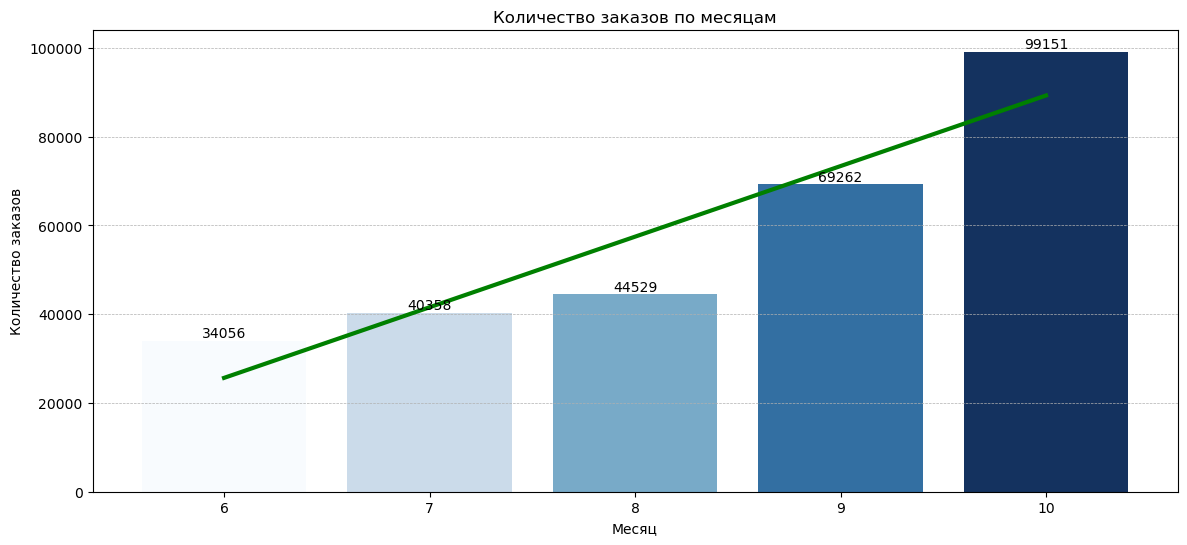

In [36]:
plt.figure(figsize=(14, 6))
ax=sns.barplot(
    x='month',
    y='order_id',
    data=group_month,
    hue='month',        
    palette='Blues',   
    legend=False
)

x_pos=np.arange(len(group_month))
y_values=group_month['order_id'].values


z=np.polyfit(x_pos, y_values, 1)
p=np.poly1d(z)

ax.plot(x_pos, p(x_pos), color='green', linewidth=3, linestyle='-', label='Тренд')

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x()+p.get_width()/2., p.get_height()),
        ha='center', va='bottom', fontsize=10
    )

plt.title('Количество заказов по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')
plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.show()

Исходя из увиденного очевидно, что с наступлением осени действительно наблюдается рост числа заказов по сравнению с летними месяцами.

##### 3.1.2. Для осеннего и летнего периодов 
Для осеннего и летнего периодов сравним распределение заказов билетов по разным категориям: тип мероприятия, тип устройства, категория мероприятия по возрастному рейтингу. Результаты визуализируем графиком, который поможет сопоставить значения для летнего и осеннего сезонов.

Посмотрим на общее число заказов по сезонам.

In [37]:
group_season=final_tickets.groupby('season')['order_id'].count().reset_index(name='count_order')
total_orders=group_season['count_order'].sum()
group_season['ratio_season']=(group_season['count_order']/total_orders).round(2)

group_season

,season,count_order,ratio_season
0,лето,118943,0.41
1,осень,168413,0.59


Сгруппируем по сезону и по типу мероприятия.

In [38]:
group_event=final_tickets.groupby(['season', 'event_type_main'])['order_id'].count().reset_index(name='count_event')
group_season_event=pd.merge(group_event, group_season, on='season')
group_season_event['ratio_event']=(group_season_event['count_event']/group_season_event['count_order']).round(2)

group_season_event

,season,event_type_main,count_event,count_order,ratio_season,ratio_event
0,лето,выставки,2407,118943,0.41,0.02
1,лето,другое,32205,118943,0.41,0.27
2,лето,концерты,50766,118943,0.41,0.43
3,лето,спорт,3003,118943,0.41,0.03
4,лето,стендап,6346,118943,0.41,0.05
5,лето,театр,23943,118943,0.41,0.20
6,лето,ёлки,273,118943,0.41,0.00
7,осень,выставки,2402,168413,0.59,0.01
8,осень,другое,33069,168413,0.59,0.20
9,осень,концерты,62735,168413,0.59,0.37


Сгруппируем по сезону и по типу устройства.

In [39]:
group_device=final_tickets.groupby(['season','device_type_canonical'])['order_id'].count().reset_index(name='count_device')
group_season_device=pd.merge(group_device, group_season, on='season')
group_season_device['ratio_device']=(group_season_device['count_device']/group_season_device['count_order']).round(2)

group_season_device

,season,device_type_canonical,count_device,count_order,ratio_season,ratio_device
0,лето,desktop,23046,118943,0.41,0.19
1,лето,mobile,95897,118943,0.41,0.81
2,осень,desktop,34290,168413,0.59,0.20
3,осень,mobile,134123,168413,0.59,0.80


Сгруппируем по сезону и по возрастному ограничению.

In [40]:
group_age=final_tickets.groupby(['season','age_limit'])['order_id'].count().reset_index(name='count_age')
group_season_age=pd.merge(group_age, group_season, on='season')
group_season_age['ratio_age']=(group_season_age['count_age']/group_season_age['count_order']).round(2)

group_season_age

,season,age_limit,count_age,count_order,ratio_season,ratio_age
0,лето,0,21272,118943,0.41,0.18
1,лето,6,21664,118943,0.41,0.18
2,лето,12,24430,118943,0.41,0.21
3,лето,16,33755,118943,0.41,0.28
4,лето,18,17822,118943,0.41,0.15
5,осень,0,39704,168413,0.59,0.24
6,осень,6,29677,168413,0.59,0.18
7,осень,12,37258,168413,0.59,0.22
8,осень,16,44208,168413,0.59,0.26
9,осень,18,17566,168413,0.59,0.10


Для построения графика объединим расчёты долей в одну таблицу.

In [41]:
group_season_event_mod=group_season_event.copy()
group_season_event_mod['category'] = 'event_type'
group_season_event_mod=group_season_event_mod.rename(columns={'event_type_main': 'value', 'ratio_event': 'ratio'})

group_season_device_mod=group_season_device.copy()
group_season_device_mod['category'] = 'device_type'
group_season_device_mod=group_season_device_mod.rename(columns={'device_type_canonical': 'value', 'ratio_device': 'ratio'})

group_season_age_mod=group_season_age.copy()
group_season_age_mod['category'] = 'age_limit'
group_season_age_mod=group_season_age_mod.rename(columns={'age_limit': 'value', 'ratio_age': 'ratio'})

all_data=pd.concat([
    group_season_event_mod[['season', 'value', 'category', 'ratio']],
    group_season_device_mod[['season', 'value', 'category', 'ratio']],
    group_season_age_mod[['season', 'value', 'category', 'ratio']]
], ignore_index=True)

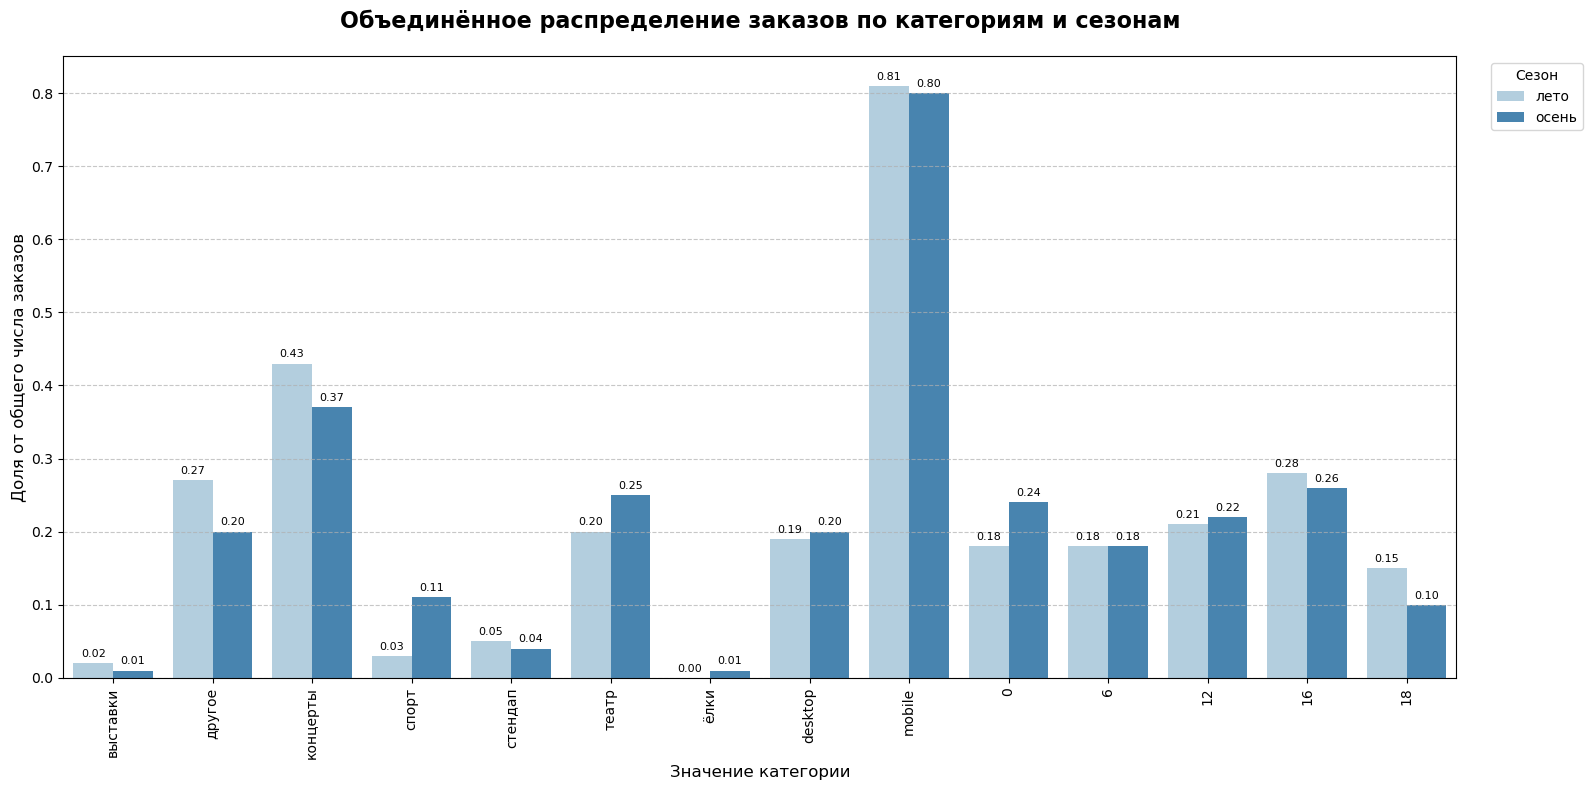

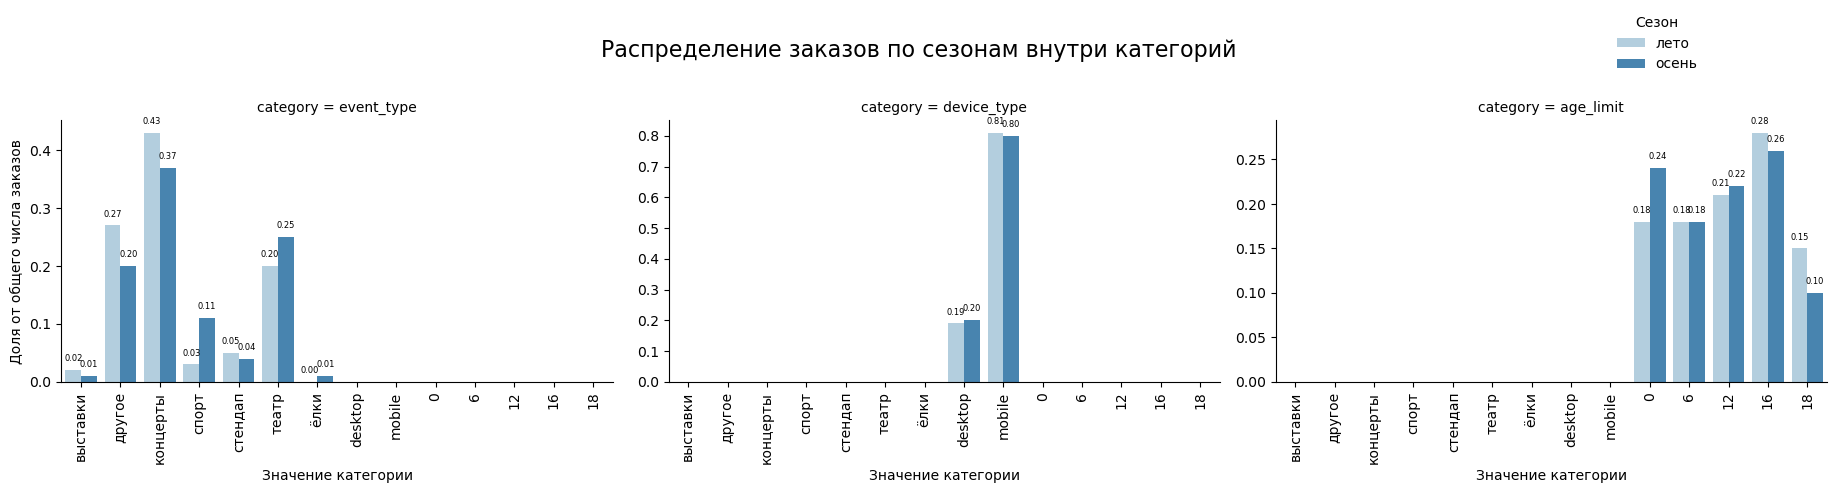

In [42]:
fig, ax=plt.subplots(figsize=(16, 8))

sns.barplot(
    data=all_data,
    x='value',
    y='ratio',
    hue='season',
    palette='Blues',
    ax=ax
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f',
        label_type='edge',
        padding=3,
        fontsize=8,
        color='black'
    )

ax.set_xlabel('Значение категории', fontsize=12)
ax.set_ylabel('Доля от общего числа заказов', fontsize=12)
ax.tick_params(axis='x', rotation=90)
ax.legend(title='Сезон', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.title(
    'Объединённое распределение заказов по категориям и сезонам',
    fontsize=16, fontweight='bold', pad=20
)
plt.tight_layout()
plt.show()

g=sns.FacetGrid(
    all_data,
    col='category',
    height=4.5,
    aspect=1.3,
    sharey=False
)
g.map_dataframe(sns.barplot, x='value', y='ratio', hue='season', palette='Blues')
g.set_axis_labels('Значение категории', 'Доля от общего числа заказов')
g.add_legend(title='Сезон', bbox_to_anchor=(0.9, 1.1), loc='upper center')
g.fig.suptitle('Распределение заказов по сезонам внутри категорий', fontsize=16, y=1.02)
g.set_xticklabels(rotation=90)
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='%.2f',
            label_type='edge',
            padding=5,
            fontsize=6,
            color='black'
        )
plt.tight_layout()
plt.show()

По типу события:
- лето:
    - концерты — 43%;
    - «Другое» (сложно классифицировать) — 27%;
    - театральные мероприятия — 20%;
    - стендап, спорт, выставки — 2–5%;
    - ёлки — 0%.
- осень:
    - концерты — 37%;
    - театр — 25% (рост);
    - спорт — 11% (рост относительно лета);
    - ёлки — 1% (появление заказов).

По типу устройства:
- летом и осенью: мобильные устройства — 80–81%;
- стационарные устройства - 19-20%

По возрастному рейтингу:
- лето:
    - 16+ — 28%;
    - 12+ — 21%;
    - 6+ — 18%;
    - для всех возрастов(0+) — 18%;
    - 18+ — менее популярны(15%).
- осень:
    - 16+ — 26%;
    - для всех возрастов(0+) — 24% (рост);
    - наблюдается снижение интереса к мероприятиям для взрослых.

<b>Выводы:</b>
- осенью растёт интерес к спортивным мероприятиям, театральным постановкам, мероприятиям для всей семьи.
- мобильные устройства — основной канал заказов (80–81 %) вне зависимости от сезона.
- ёлки начинают набирать популярность осенью (1 %).

##### 3.1.3. Изменение выручки с продажи одного билета 
Изучим изменение выручки с продажи одного билета в зависимости от типа мероприятия летом и осенью. Для каждого типа мероприятия рассчитаем среднее значение выручки с одного билета, затем найдём относительное изменение осенних значений по сравнению с летними. Результат отобразим на графике.

In [43]:
avg_ticket_season_event= final_tickets.groupby(['season','event_type_main'])['one_ticket_revenue_rub'].mean().round(2).reset_index(name='avg_one_ticket')
avg_ticket_season_event=avg_ticket_season_event.sort_values(by='avg_one_ticket', ascending=False)

avg_ticket_season_event

,season,event_type_main,avg_one_ticket
2,лето,концерты,304.79
6,лето,ёлки,271.44
9,осень,концерты,268.37
11,осень,стендап,231.12
13,осень,ёлки,229.59
4,лето,стендап,218.52
5,лето,театр,214.14
12,осень,театр,175.98
7,осень,выставки,91.91
0,лето,выставки,86.74


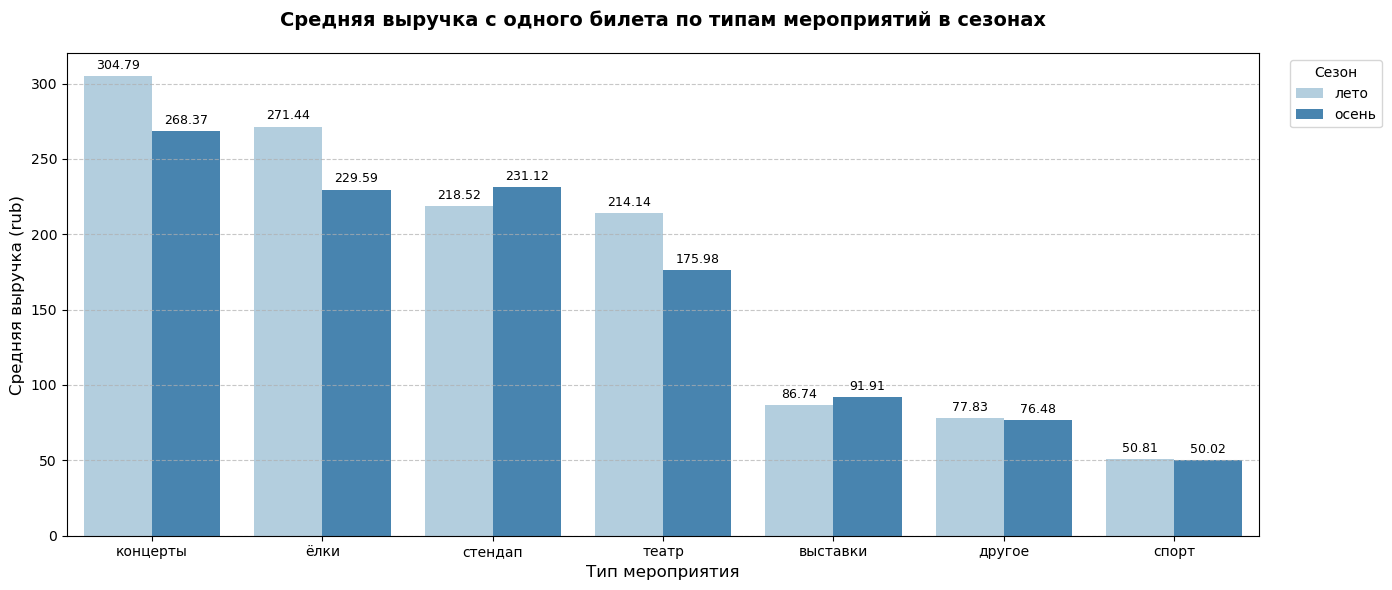

In [44]:
plt.figure(figsize=(14, 6))

ax=sns.barplot(
    x='event_type_main',
    y='avg_one_ticket',
    hue='season',
    palette='Blues',
    data=avg_ticket_season_event
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f',
        label_type='edge',
        padding=3,
        fontsize=9,
        color='black'
    )

plt.title('Средняя выручка с одного билета по типам мероприятий в сезонах', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Тип мероприятия', fontsize=12)
plt.ylabel('Средняя выручка (rub)', fontsize=12)
plt.legend(title='Сезон', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Найдём относительное изменение осенних значений по сравнению с летними.

In [45]:
dif_val_aut_sum=avg_ticket_season_event.pivot_table(index='event_type_main', columns='season', values='avg_one_ticket')
dif_val_aut_sum['dif_value']=(((dif_val_aut_sum['осень']-dif_val_aut_sum['лето'])/dif_val_aut_sum['лето'])*100).round(2)

dif_val_aut_sum

season,лето,осень,dif_value
event_type_main,,,
выставки,86.74,91.91,5.96
другое,77.83,76.48,-1.73
концерты,304.79,268.37,-11.95
спорт,50.81,50.02,-1.55
стендап,218.52,231.12,5.77
театр,214.14,175.98,-17.82
ёлки,271.44,229.59,-15.42


<b>Концерты:</b> осенью число заказов немного снизилось, а средняя цена билета заметно упала — вероятно, из‑за снижения популярности крупных музыкальных мероприятий. Летом билеты стоили дороже.

<b>Стендап:</b> осенью доля заказов немного выросла, как и средняя цена билета. Это может свидетельствовать о росте популярности стендап‑шоу в этот период.

<b>Ёлки:</b> осенью наблюдается небольшой рост числа заказов, но средняя цена билета существенно снижается — возможно, это связано с сезонным снижением цен на мероприятия к новогодним праздникам.

<b>Театр:</b> осенью средняя цена билета снизилась, что может быть связано с открытием театрального сезона и снижением цен для повышения доступности. При этом спрос вырос.

<b>Выставки:</b> доля заказов немного снизилась, а средняя цена билета слегка выросла. Возможно, осенью проходят более крупные или специализированные выставки с высокими ценами, но узкой аудиторией.

<b>Спортивные мероприятия:</b> средняя цена билета минимально изменилась в меньшую сторону, а доля заказов выросла. Это говорит о стабильном спросе в оба сезона.

<b>Другое:</b> снизились и доля заказов, и средняя цена билета. Вероятно, это связано с изменением состава мероприятий в этой категории и общим снижением интереса к ним осенью.

<b>Общий вывод:</b> осень приводит к изменениям в спросе на разные типы мероприятий и корректировке цен в зависимости от сезона.

#### 3.2. Осенняя активность пользователей

Изучим активность пользователей осенью 2024 года. В нашем распоряжении данные за два осенних месяца.

##### 3.2.1. Анализ динамики изменений по дням
Проанализируем динамику для:
- общего числа заказов;
- количества активных пользователей `DAU`;
- среднего числа заказов на одного пользователя;
- средней стоимости одного билета.

In [46]:
autumn_info=final_tickets[(final_tickets['season']=='осень')]

day_autumn_info=autumn_info.groupby('created_dt_msk').agg(
    all_orders=('order_id', 'count'),                 
    dau_users=('user_id', 'nunique'),                 
).reset_index()

day_autumn_info['avg_orders_user']=(day_autumn_info['all_orders']/day_autumn_info['dau_users']).round(2)
day_autumn_info['avg_ticket_revenue']=autumn_info.groupby('created_dt_msk')['one_ticket_revenue_rub'].mean().round(2).values

day_autumn_info.head()

,created_dt_msk,all_orders,dau_users,avg_orders_user,avg_ticket_revenue
0,2024-09-01,1327,564,2.35,200.17
1,2024-09-02,1376,573,2.40,190.02
2,2024-09-03,5094,777,6.56,80.65
3,2024-09-04,1760,684,2.57,179.36
4,2024-09-05,1941,738,2.63,189.80


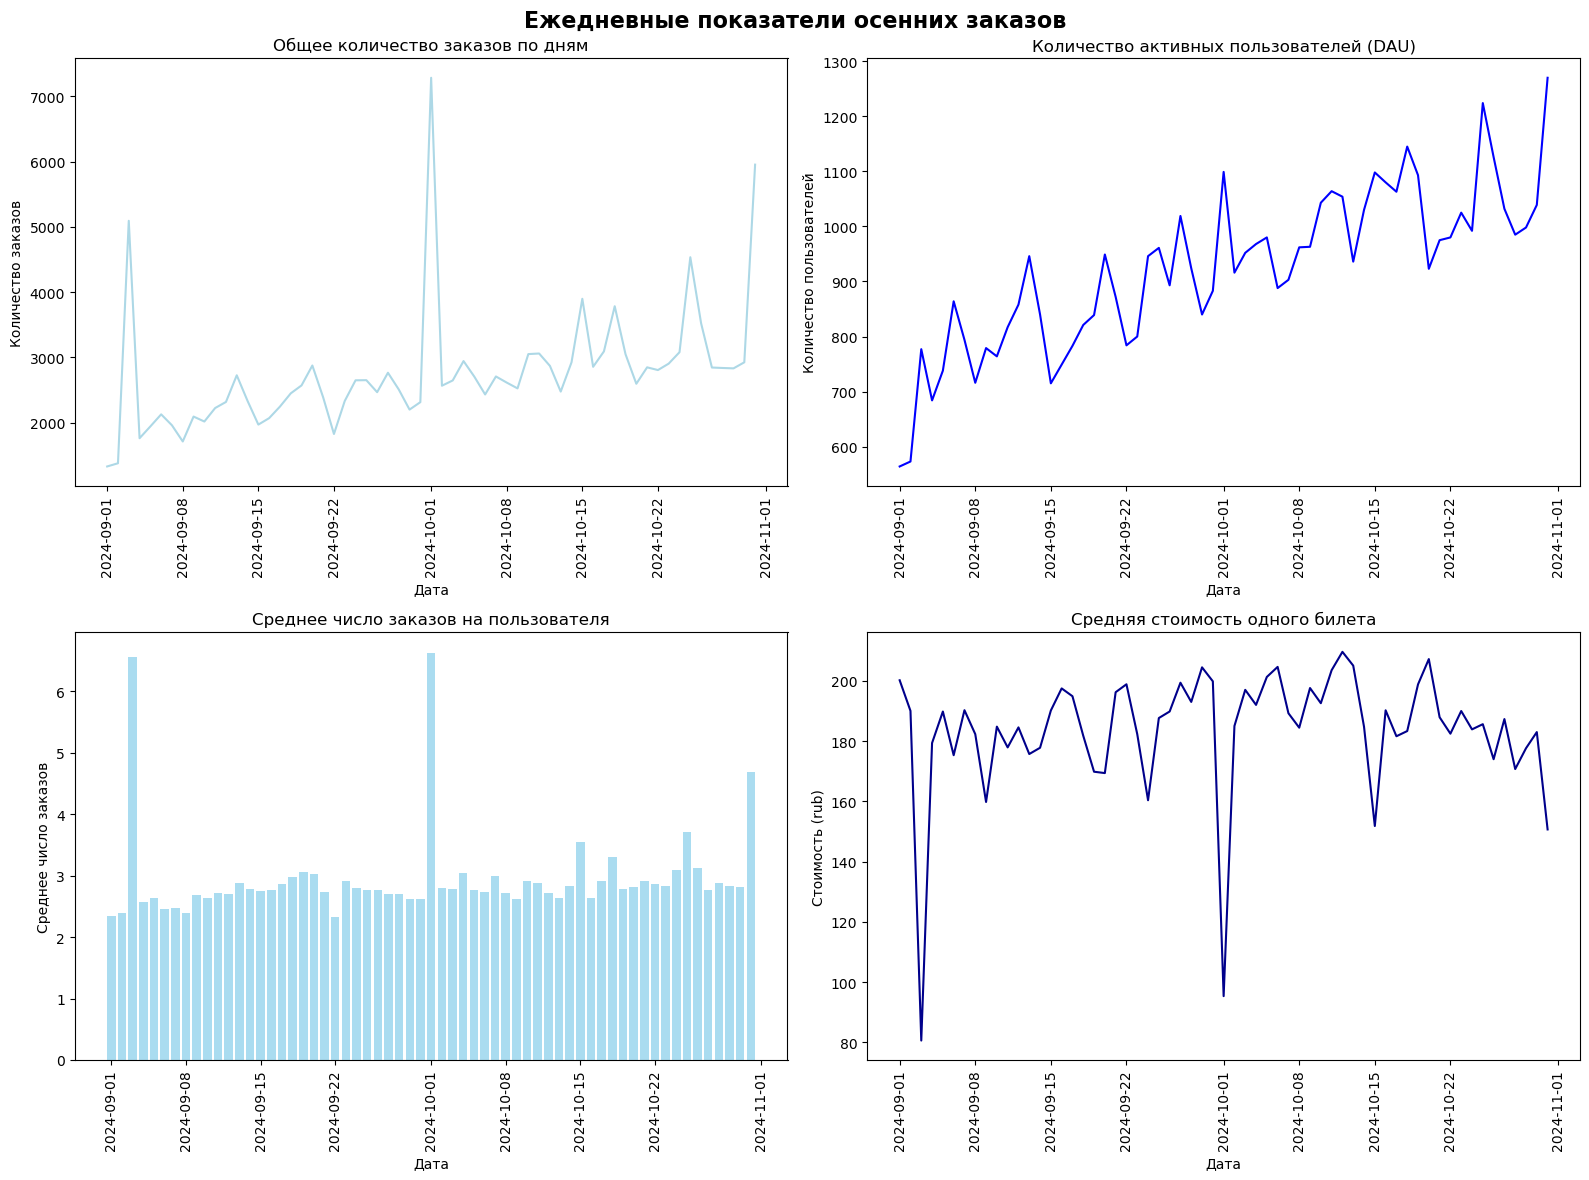

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Ежедневные показатели осенних заказов', fontsize=16, fontweight='bold')

axes[0, 0].plot(day_autumn_info['created_dt_msk'], day_autumn_info['all_orders'], color='lightblue')
axes[0, 0].set_title('Общее количество заказов по дням')
axes[0, 0].set_xlabel('Дата')
axes[0, 0].set_ylabel('Количество заказов')
axes[0, 0].tick_params(axis='x', rotation=90)

axes[0, 1].plot(day_autumn_info['created_dt_msk'], day_autumn_info['dau_users'], color='blue')
axes[0, 1].set_title('Количество активных пользователей (DAU)')
axes[0, 1].set_xlabel('Дата')
axes[0, 1].set_ylabel('Количество пользователей')
axes[0, 1].tick_params(axis='x', rotation=90)

axes[1, 0].bar(day_autumn_info['created_dt_msk'], day_autumn_info['avg_orders_user'], color='skyblue', alpha=0.7)
axes[1, 0].set_title('Среднее число заказов на пользователя')
axes[1, 0].set_xlabel('Дата')
axes[1, 0].set_ylabel('Среднее число заказов')
axes[1, 0].tick_params(axis='x', rotation=90)

axes[1, 1].plot(day_autumn_info['created_dt_msk'], day_autumn_info['avg_ticket_revenue'], color='darkblue')
axes[1, 1].set_title('Средняя стоимость одного билета')
axes[1, 1].set_xlabel('Дата')
axes[1, 1].set_ylabel('Стоимость (rub)')
axes[1, 1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

Заказы:
- с начала сентября до конца октября наблюдается стабильный рост числа заказов;
- пики были в начале сентября (~ 5 000 заказов), конец сентября (~ 7 500 заказов), конец октября (~ 6 000 заказов);
- в середине и конце октября наблюдаются дни с высоким числом заказов.

Активные пользователи:
- растут с начала сентября до конца октября (с ~ 550 до ~ 1 300 пользователей);
- есть рост заказов и активных пользователей, это указывает на повышение вовлечённости.

Среднее число заказов на пользователя:
- в целом наблюдается стабильная картина - 2–3 заказа в день на пользователя;
- есть значения выше - начало и конец сентября (> 6 заказов на пользователя), конец октября (~ 5 заказов) — возможно, из‑за акций или крупных мероприятий.

Средняя стоимость билета:
- на протяжении этих месяцев значительно меняется;
- в сентябре - высокая в начале месяца (~ 200 руб. 1 сентября), резкое падение 3 сентября (~ 80 руб.), ещё одно падение в конце сентября (~ 100 руб.).
- в октябре видим заметное снижение стоимости, особенно в конце месяца (~ 150 руб.) — возможно, сезонные скидки или изменение ценовой политики.

<b>Краткий итог:</b>
- вовлечённость растёт: больше заказов и пользователей.
- активность на пользователя стабильна (2–3 заказа/день), но есть всплески (до 5–6 заказов) в ключевые периоды.
- цены падают: от ~ 200 руб. в начале сентября до ~ 150 руб. в конце октября — вероятны скидки или смена стратегии ценообразования.

##### 3.2.2. Анализ недельной цикличности
Выделим день недели и сравним пользовательскую активность в будни и выходные.
Для начала создадим дополнительные столбцы с днём недели и идентификатором будний/выходной.

In [48]:
day_autumn_info=day_autumn_info.copy()
day_autumn_info['day_of_week']=day_autumn_info['created_dt_msk'].dt.day_name()  
day_autumn_info['weekend']=day_autumn_info['created_dt_msk'].dt.dayofweek>4  

day_autumn_info.head()

,created_dt_msk,all_orders,dau_users,avg_orders_user,avg_ticket_revenue,day_of_week,weekend
0,2024-09-01,1327,564,2.35,200.17,Sunday,True
1,2024-09-02,1376,573,2.40,190.02,Monday,False
2,2024-09-03,5094,777,6.56,80.65,Tuesday,False
3,2024-09-04,1760,684,2.57,179.36,Wednesday,False
4,2024-09-05,1941,738,2.63,189.80,Thursday,False


Сделаем группировку по дням недели и покажем статистику.

In [49]:
weekday_grouped=day_autumn_info.groupby('day_of_week').agg(
    total_orders=('all_orders', 'sum'),
    total_users=('dau_users', 'sum'),
    avg_orders_per_day=('all_orders', 'mean'),
    avg_users_per_day=('dau_users', 'mean'),
    avg_ticket_revenue=('avg_ticket_revenue', 'mean')
).round(2).reset_index()

days_order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'] #порядок дней

existing_days=[day for day in days_order if day in weekday_grouped['day_of_week'].values]
weekday_grouped=weekday_grouped.set_index('day_of_week').loc[existing_days].reset_index()

weekday_grouped['avg_orders_user_weekly']=(
    weekday_grouped['total_orders'] / weekday_grouped['total_users']
).round(2)

weekday_grouped

,day_of_week,total_orders,total_users,avg_orders_per_day,avg_users_per_day,avg_ticket_revenue,avg_orders_user_weekly
0,Monday,21495,7677,2388.33,853.00,184.67,2.80
1,Tuesday,31437,8407,3493.00,934.11,156.93,3.74
2,Wednesday,22853,8306,2539.22,922.89,185.82,2.75
3,Thursday,27114,8648,3012.67,960.89,182.19,3.14
4,Friday,24811,8179,3101.38,1022.38,185.52,3.03
5,Saturday,21328,7683,2666.00,960.38,192.61,2.78
6,Sunday,19375,7398,2152.78,822.00,197.78,2.62


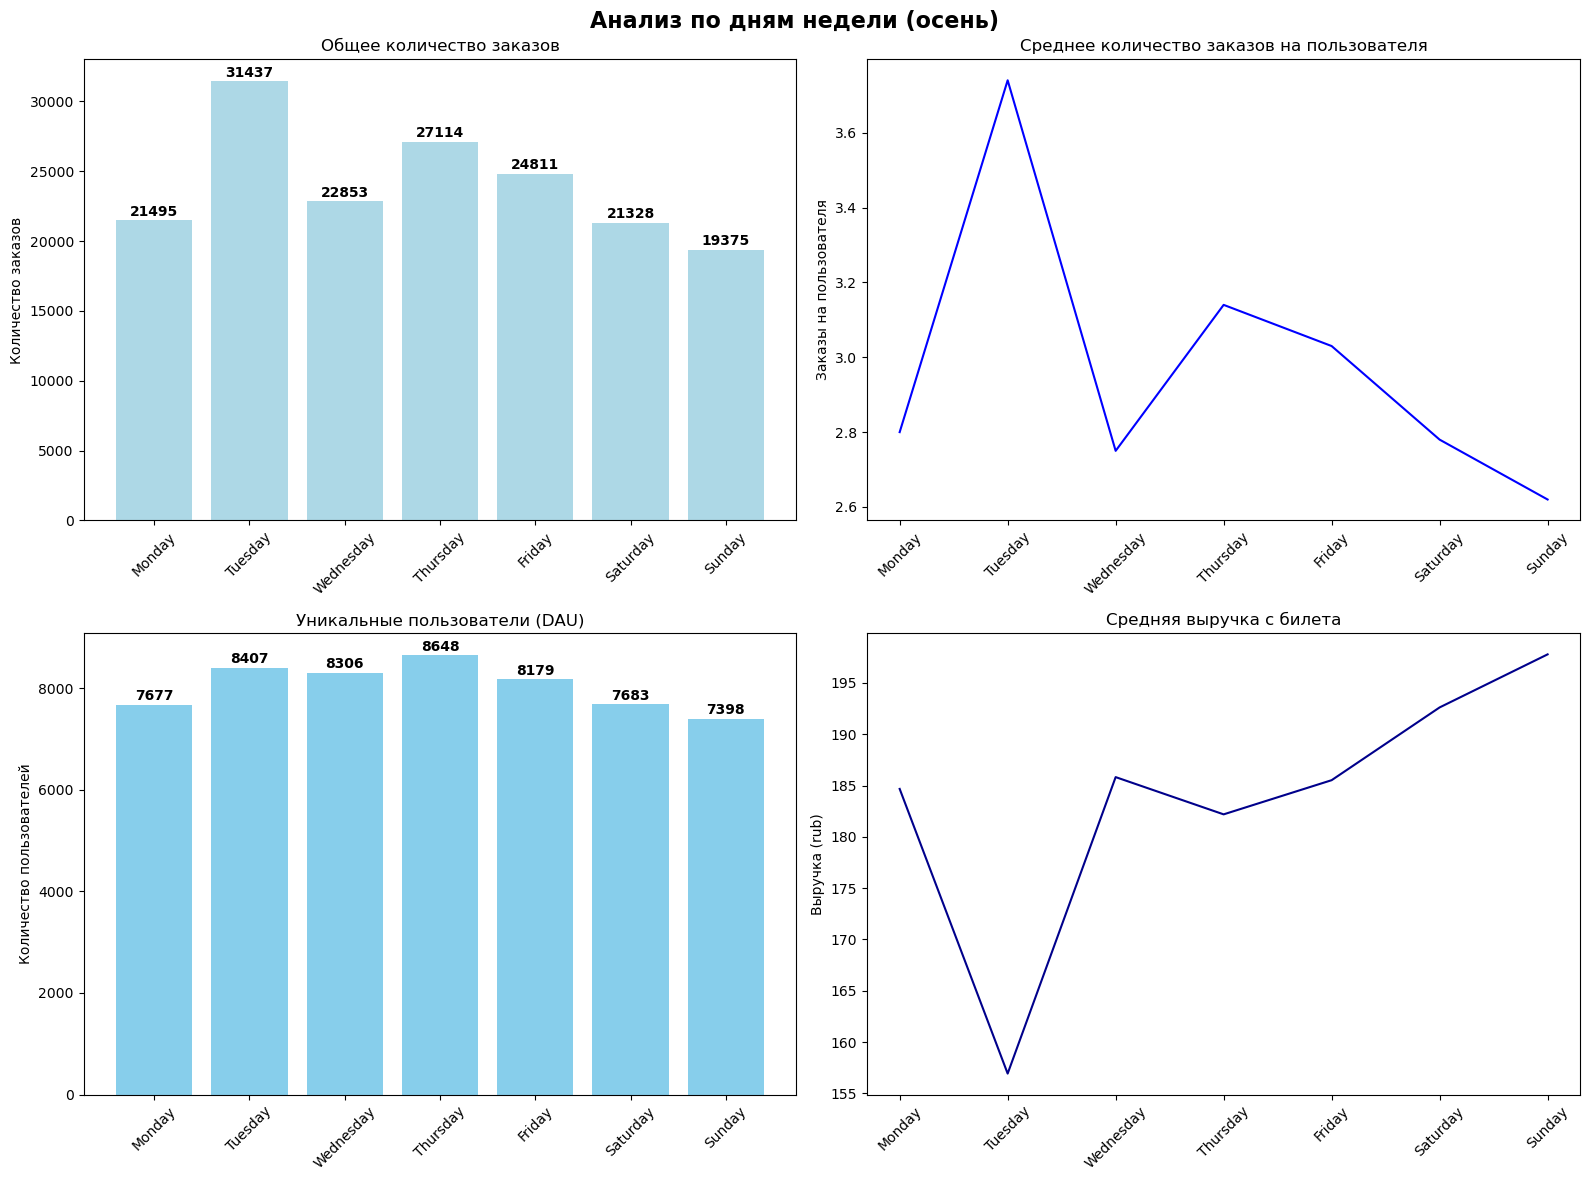

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Анализ по дням недели (осень)', fontsize=16, fontweight='bold')

axes[0, 0].bar(weekday_grouped['day_of_week'],
             weekday_grouped['total_orders'],
             color='lightblue')
axes[0, 0].set_title('Общее количество заказов')
axes[0, 0].set_ylabel('Количество заказов')
axes[0, 0].tick_params(axis='x', rotation=45)

for i, v in enumerate(weekday_grouped['total_orders']):
    axes[0, 0].text(i, v + max(weekday_grouped['total_orders']) * 0.01,
                 str(int(v)), ha='center', fontweight='bold')

axes[0, 1].plot(weekday_grouped['day_of_week'],
               weekday_grouped['avg_orders_user_weekly'],
               color='blue')
axes[0, 1].set_title('Среднее количество заказов на пользователя')
axes[0, 1].set_ylabel('Заказы на пользователя')
axes[0, 1].tick_params(axis='x', rotation=45)

axes[1, 0].bar(weekday_grouped['day_of_week'],
             weekday_grouped['total_users'],
             color='skyblue')
axes[1, 0].set_title('Уникальные пользователи (DAU)')
axes[1, 0].set_ylabel('Количество пользователей')
axes[1, 0].tick_params(axis='x', rotation=45)

for i, v in enumerate(weekday_grouped['total_users']):
    axes[1, 0].text(i, v + max(weekday_grouped['total_users']) * 0.01,
                 str(int(v)), ha='center', fontweight='bold')

axes[1, 1].plot(weekday_grouped['day_of_week'],
               weekday_grouped['avg_ticket_revenue'],
               color='darkblue')
axes[1, 1].set_title('Средняя выручка с билета')
axes[1, 1].set_ylabel('Выручка (rub)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Разделим информацию на будние и выходные, построим только таблицу для наглядности.

In [51]:
weekend_grouped=day_autumn_info.groupby('weekend').agg(
    total_orders=('all_orders', 'sum'),
    total_users=('dau_users', 'sum'),
    avg_orders_per_days=('all_orders', 'mean'),
    avg_users_per_days=('dau_users', 'mean'),
    avg_ticket_revenue=('avg_ticket_revenue', 'mean')
).round(2).reset_index()

weekend_grouped['period_type']=weekend_grouped['weekend'].map(
    {True: 'Weekends', False: 'Weekdays'}
)
weekend_grouped.drop('weekend', axis=1, inplace=True)

weekend_grouped['avg_orders_user_period']=(
    weekend_grouped['total_orders']/weekend_grouped['total_users']
).round(2)

weekend_grouped

,total_orders,total_users,avg_orders_per_days,avg_users_per_days,avg_ticket_revenue,period_type,avg_orders_user_period
0,127710,41217,2902.50,936.75,178.88,Weekdays,3.1
1,40703,15081,2394.29,887.12,195.35,Weekends,2.7


Вторник — пик активности по количеству заказов и среднему числу заказов на пользователя (вероятно, из‑за акций в начале недели), далее идёт четверг.

В выходные активность снижается, особенно в воскресенье.

При этом средняя стоимость чека в выходные выше.

<b>Общий вывод:</b> активность покупателей и объём заказов растут в будние дни, что, вероятно, связано с привычным ритмом жизни в рабочие дни. В выходные картина меняется: хотя заказов и пользователей становится меньше, средняя стоимость покупки возрастает.

#### 3.3. Популярные события и партнёры

Посмотрим, как события распределены по регионам и партнёрам. Это позволит выделить ключевые регионы и партнёров, которые вносят наибольший вклад в выручку.

##### 3.3.1. Для каждого региона
Посчитаем уникальное количество мероприятий и общее число заказов, чтобы понять в каких регионах предлагается наибольшее разнообразие мероприятий. Посчитаем доли.

In [52]:
group_region=(
    final_tickets
    .groupby('region_name')
    .agg(
        unique_events=('event_id', 'nunique'), 
        total_orders=('order_id', 'count')      
        )
    .reset_index()
)

group_region['ratio_event']=(group_region['unique_events']/group_region['unique_events'].sum()).round(2) 
group_region['ratio_order']=(group_region['total_orders']/group_region['total_orders'].sum()).round(2)

group_region=group_region.sort_values(by='ratio_event', ascending=False)

group_region.head(15)

,region_name,unique_events,total_orders,ratio_event,ratio_order
23,Каменевский регион,5934,89658,0.27,0.31
60,Североярская область,3798,43724,0.17,0.15
57,Светополянский округ,1068,7486,0.05,0.03
77,Широковская область,1225,16099,0.05,0.06
74,Травяная область,683,5036,0.03,0.02
52,Речиновская область,701,6265,0.03,0.02
65,Солнечнореченская область,358,3974,0.02,0.01
11,Горицветская область,551,5152,0.02,0.02
69,Тепляковская область,528,4383,0.02,0.02
42,Медовская область,503,13889,0.02,0.05


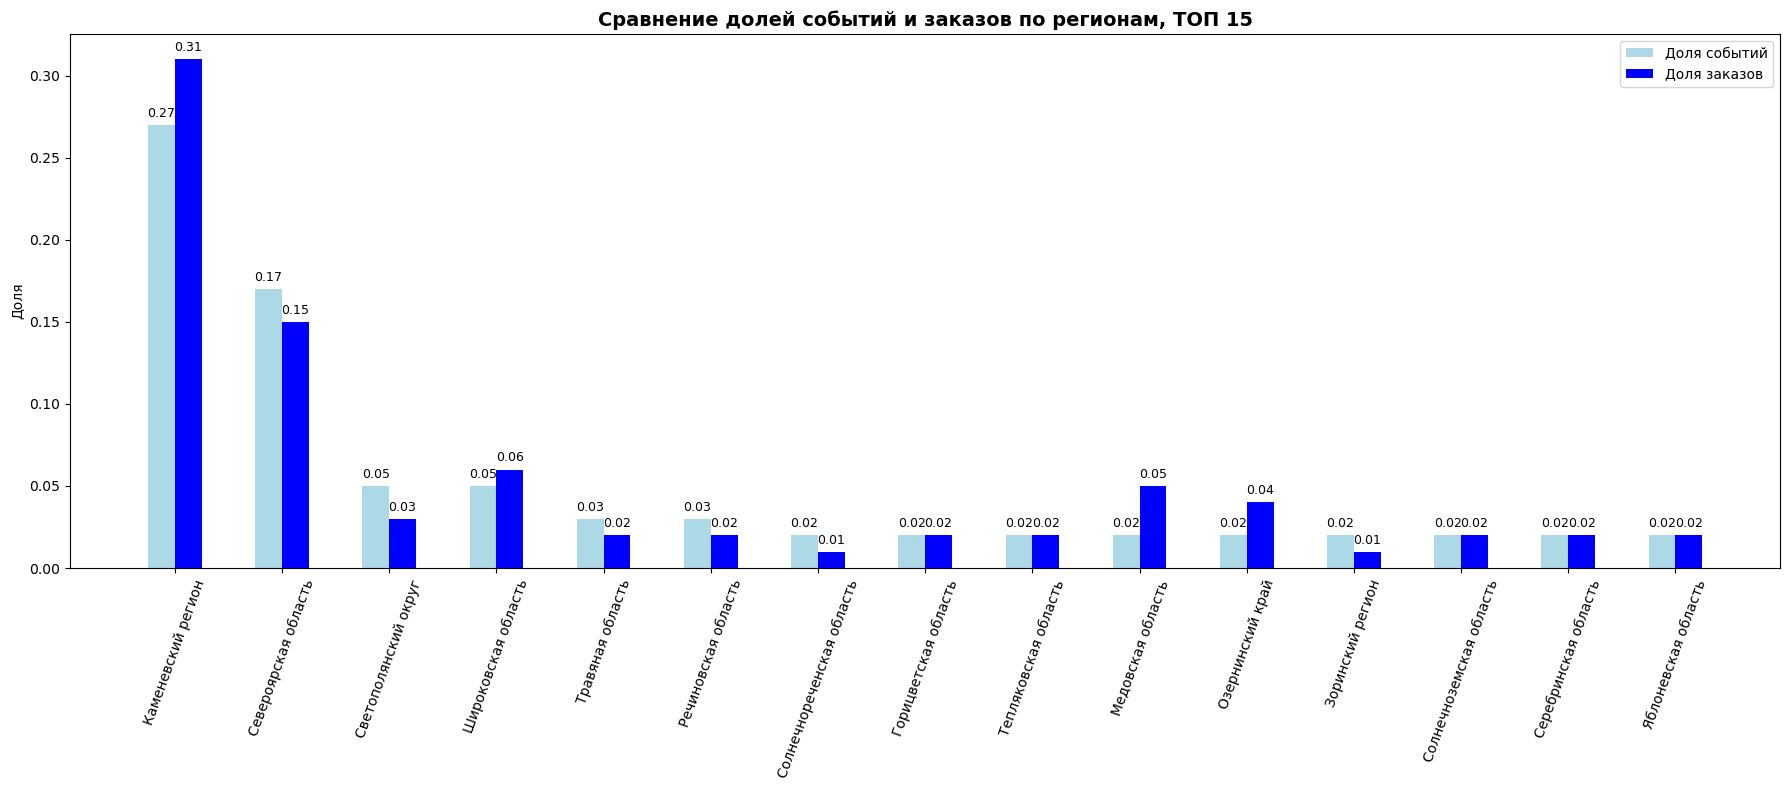

In [53]:
group_region_15=group_region.head(15)

fig, ax=plt.subplots(figsize=(18, 8))

x=range(len(group_region_15))
width = 0.25

bars1=ax.bar([i - width/2 for i in x], group_region_15['ratio_event'],
             width, label='Доля событий', color='lightblue')

bars2=ax.bar([i + width/2 for i in x], group_region_15['ratio_order'],
             width, label='Доля заказов', color='blue')

ax.set_ylabel('Доля')
ax.set_title('Сравнение долей событий и заказов по регионам, ТОП 15', fontsize=14, fontweight='bold',)
ax.set_xticks(x)
ax.set_xticklabels(group_region_15['region_name'], rotation=70)
ax.legend()

def add_value_labels(bars, ax):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + max(group_region_15['ratio_event'].max(), group_region_15['ratio_order'].max()) * 0.01,
            f'{height:.2f}',
            ha='center', va='bottom',
            fontsize=9, color='black'
        )

add_value_labels(bars1, ax)
add_value_labels(bars2, ax)

plt.tight_layout()
plt.show()

Регионы, где спрос ≈ предложение:
- Каменевский регион (27% событий и 31% заказов);
- Североярская область (17% и 15%);
- Широковская область (5% и 6%).

Регионы, где спрос > предложени:
- Медовская область (2% событий и 5% заказов);
- Озернинский край	(2% и  4% заказов).

Эти  регионы имеют потенциал для роста.

Регионы с избыточным предложением (предложение > спроса):
- Светополянский округ (5% событий и 3% заказов);
- Речиновская область (3% и 2%).

В таких регионах может возникнуть перенасыщение событиями без пользовательского спроса.

##### 3.3.2. Для каждого билетного партнёра 

Посчитаем общее число уникальных мероприятий, обработанных заказов и суммарную выручку с заказов билетов. Выделим наиболее активных партнёрах. Рассмотрим и долевую часть.

In [54]:
group_service=(
    final_tickets
    .groupby('service_name')
    .agg(
        unique_events=('event_id', 'nunique'), 
        total_orders=('order_id', 'count'),
        total_revenue=('revenue_rub', 'sum')
    )
    .reset_index()
)
group_service['total_revenue'] = group_service['total_revenue'].astype(int)

group_service['ratio_event']=(group_service['unique_events']/group_service['unique_events'].sum()).round(2)
group_service['ratio_order']=(group_service['total_orders']/group_service['total_orders'].sum()).round(2)
group_service['ratio_revenue']=(group_service['total_revenue']/group_service['total_revenue'].sum()).round(2)

group_service = group_service.sort_values(by=['ratio_revenue', 'ratio_order'], ascending=[False, False])

group_service.head(15)

,service_name,unique_events,total_orders,total_revenue,ratio_event,ratio_order,ratio_revenue
3,Билеты без проблем,4209,62628,24322474,0.17,0.22,0.16
24,Мой билет,1300,34438,22041902,0.05,0.12,0.15
25,Облачко,2335,26402,18588613,0.10,0.09,0.12
21,Лови билет!,4859,40764,16673895,0.20,0.14,0.11
8,Весь в билетах,855,16424,16532346,0.04,0.06,0.11
5,Билеты в руки,3517,40184,13193924,0.14,0.14,0.09
19,Край билетов,252,6109,6405689,0.01,0.02,0.04
26,Прачечная,1026,10222,4746810,0.04,0.04,0.03
13,Дом культуры,272,4412,4358655,0.01,0.02,0.03
35,Яблоко,714,5004,3868336,0.03,0.02,0.03


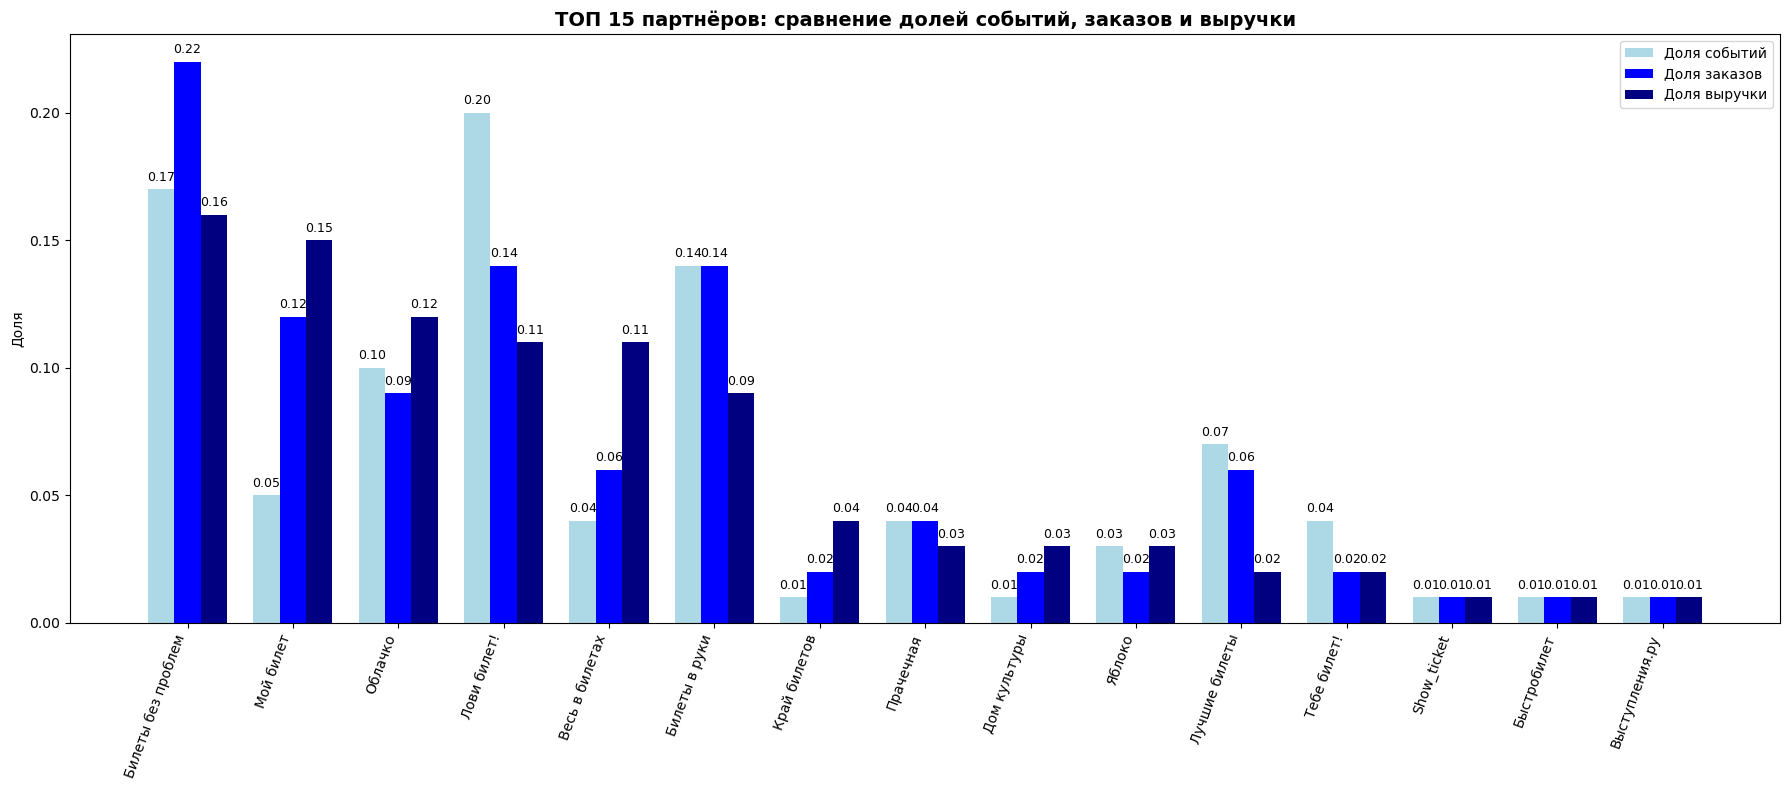

In [55]:
group_service_15=group_service.head(15)

fig, ax=plt.subplots(figsize=(18, 8))

x=range(len(group_service_15))
width = 0.25

bars1=ax.bar([i - width for i in x], group_service_15['ratio_event'],
             width, label='Доля событий', color='lightblue')
bars2=ax.bar(x, group_service_15['ratio_order'],
             width, label='Доля заказов', color='blue')
bars3=ax.bar([i + width for i in x], group_service_15['ratio_revenue'],
             width, label='Доля выручки', color='navy')

ax.set_ylabel('Доля')
ax.set_title('ТОП 15 партнёров: сравнение долей событий, заказов и выручки', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(group_service_15['service_name'], rotation=70, ha='right')
ax.legend()

max_value=group_service_15[['ratio_event', 'ratio_order', 'ratio_revenue']].max().max()
offset=max_value * 0.01

def add_value_labels(bars, ax):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + offset,
            f'{height:.2f}',
            ha='center',
            va='bottom',
            fontsize=9, color='black'
        )

add_value_labels(bars1, ax)
add_value_labels(bars2, ax)
add_value_labels(bars3, ax)

plt.tight_layout()
plt.show()

Лидеры рынка:
- "Билеты без проблем" — безусловный лидер по заказам (22%) и выручке (16%), несмотря на 2‑е место по событиям (17%);
- "Мой билет" — 2‑е место по выручке (15%) при скромном числе событий, выигрывают по выручке за счёт высоких цен/специализации;
- "Весь в билетах" — высокая выручка (11%) при малых объёмах, вероятно премиальный сегмент;
- "Облачко" — выручка (12%) выше, чем доли событий (10%) и заказов (9%).

Потенциал для роста:
- "Лови билет!" — лидер по событиям (20%), но низкая конверсия в заказы (14%) и выручку (11%), явно нужны маркетинговые улучшения.

Стабильные игроки:
- "Билеты в руки" — баланс предложения (14%) и спроса (14%), но невысокая выручка;
- "Лучшие билеты» — низкая активность по событиям (6%), но входит в ТОП 5 по предложению.

<b>ТОП 3 региона по количеству заказов и их доле:</b>
- Каменевский регион 31%;
- Североярская область 15%;
- Широковская область 6%.

<b>ТОП 3 партнёра по размеру выручки и их доле:</b>
- "Билеты без проблем" 16%;
- "Мой билет" 15%;
- "Облачко" 12%.

### 4. Статистический анализ данных

Коллеги из продуктового отдела хотят отдельно проверить несколько гипотез относительно активности пользователей мобильных и стационарных устройств. Проверим две гипотезы, которые предполагают большую активность пользователей мобильных устройств:

`1. Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.`

`2. Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.`


#### 4.1. Проверка Гипотезы 1
Нулевая гипотеза(H₀):
Среднее количество заказов на одного пользователя мобильного приложения не отличается от пользователей стационарных устройств.

Альтернативная гипотеза(H₁):
Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.

Проверим данные выборок для исключения пересечений групп.

In [56]:
print(f'Количество пользователей в осеннем периоде: {autumn_info['user_id'].nunique()}')

Количество пользователей в осеннем периоде: 15803


Проверим группы на пересечение пользователей. При наличии таковых для чистоты эксперимента исключим их из данных.

In [57]:
mobile_users=set(autumn_info[autumn_info['device_type_canonical']=='mobile']['user_id'])
desktop_users=set(autumn_info[autumn_info['device_type_canonical']=='desktop']['user_id'])
intersection_group=mobile_users&desktop_users

test_device_autumn=autumn_info[~autumn_info['user_id'].isin(intersection_group)]

print(f'Количество пользователей A/B групп в осеннем периоде: {test_device_autumn["user_id"].nunique()}')
print(f"Исключено пользователей (в пересечении): {len(intersection_group)}")

Количество пользователей A/B групп в осеннем периоде: 12554
Исключено пользователей (в пересечении): 3249


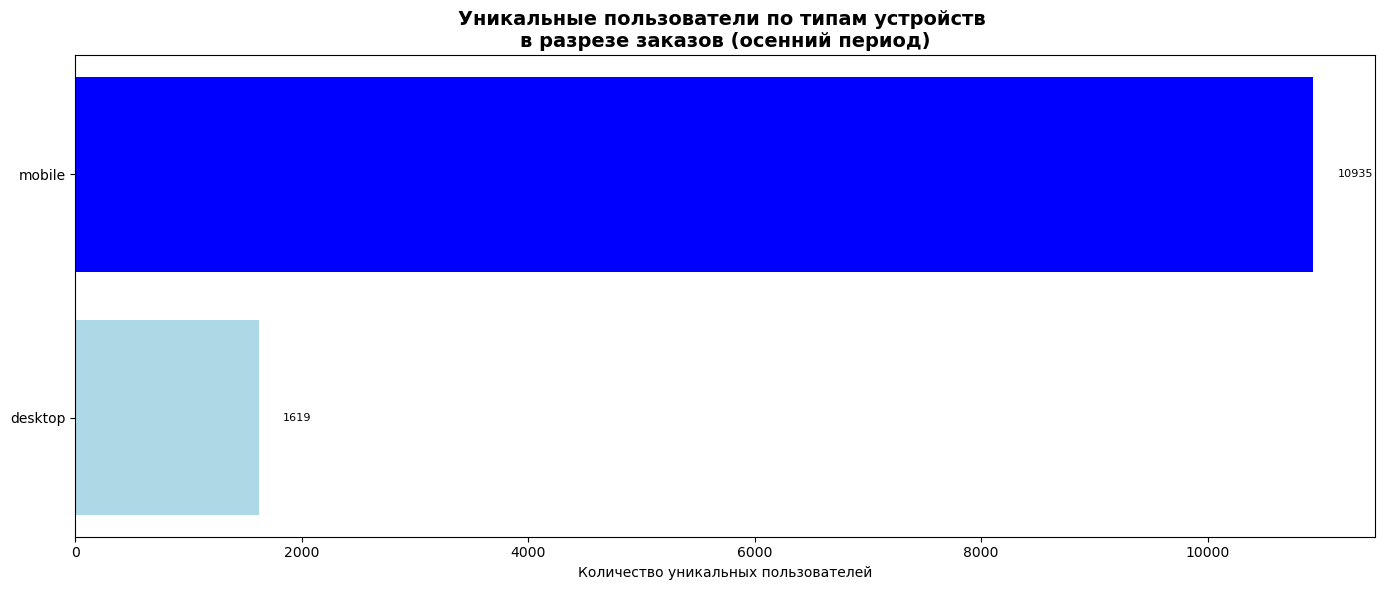

In [58]:
test_group_device=test_device_autumn.groupby('device_type_canonical')['user_id'].nunique()

sorted_data=test_group_device.sort_values(ascending=True)

fig, ax=plt.subplots(figsize=(14, 6))
bars=plt.barh(sorted_data.index, sorted_data.values, color=['lightblue', 'blue'])

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + max(sorted_data.values) * 0.02,
        bar.get_y() + bar.get_height() / 2,
        f'{int(width)}',
        ha='left',
        va='center',
        fontsize=8,
    )

plt.xlabel('Количество уникальных пользователей')
plt.title('Уникальные пользователи по типам устройств \nв разрезе заказов (осенний период)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Размеры групп значительно различаются, поэтому при выборе статистических тестов и анализе их результатов мы обязательно учтём этот фактор.

Выведем статистику по группам и изобразим на графике.

In [59]:
orders_filter_users=test_device_autumn.groupby(['user_id', 'device_type_canonical'])['order_id'].count().reset_index()

mobile_filtered=orders_filter_users[orders_filter_users['device_type_canonical']=='mobile']['order_id']
desktop_filtered=orders_filter_users[orders_filter_users['device_type_canonical']=='desktop']['order_id']

print(f"Мобильные пользователи: {len(mobile_filtered)} записей")
print(f"Стационарные пользователи: {len(desktop_filtered)} записей\n")
display(mobile_filtered.describe(), desktop_filtered.describe())

Мобильные пользователи: 10935 записей
Стационарные пользователи: 1619 записей



count    10935.000000
mean         2.856607
std          4.096213
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max        123.000000
Name: order_id, dtype: float64

count    1619.00000
mean        1.97097
std         3.05771
min         1.00000
25%         1.00000
50%         1.00000
75%         2.00000
max        56.00000
Name: order_id, dtype: float64

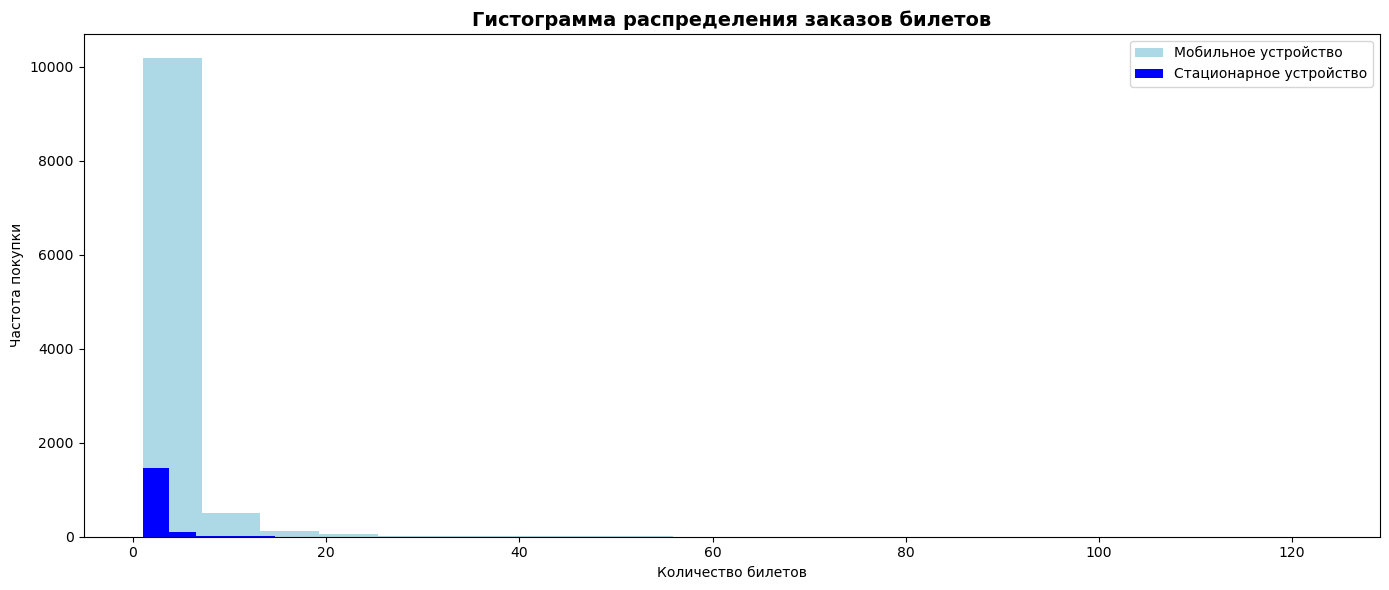

In [60]:
colors=['lightblue', 'blue']

plt.figure(figsize=(14, 6))
plt.hist(mobile_filtered, bins=20, color=colors[0], label='Мобильное устройство')
plt.hist(desktop_filtered, bins=20, color=colors[1], label='Стационарное устройство')
plt.xlabel('Количество билетов')
plt.ylabel('Частота покупки')
plt.title('Гистограмма распределения заказов билетов', fontsize=14, fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()

Выборки имеют экспоненциональное распределение. Наблюдаем большие хвосты. Сделаем сравнительное гистограммное распределение заказов билетов на мобильных устройствах и стационарных устройствах в логарифмическом масштабе, чтобы было более ясно поведение пользователей по типу девайсов.

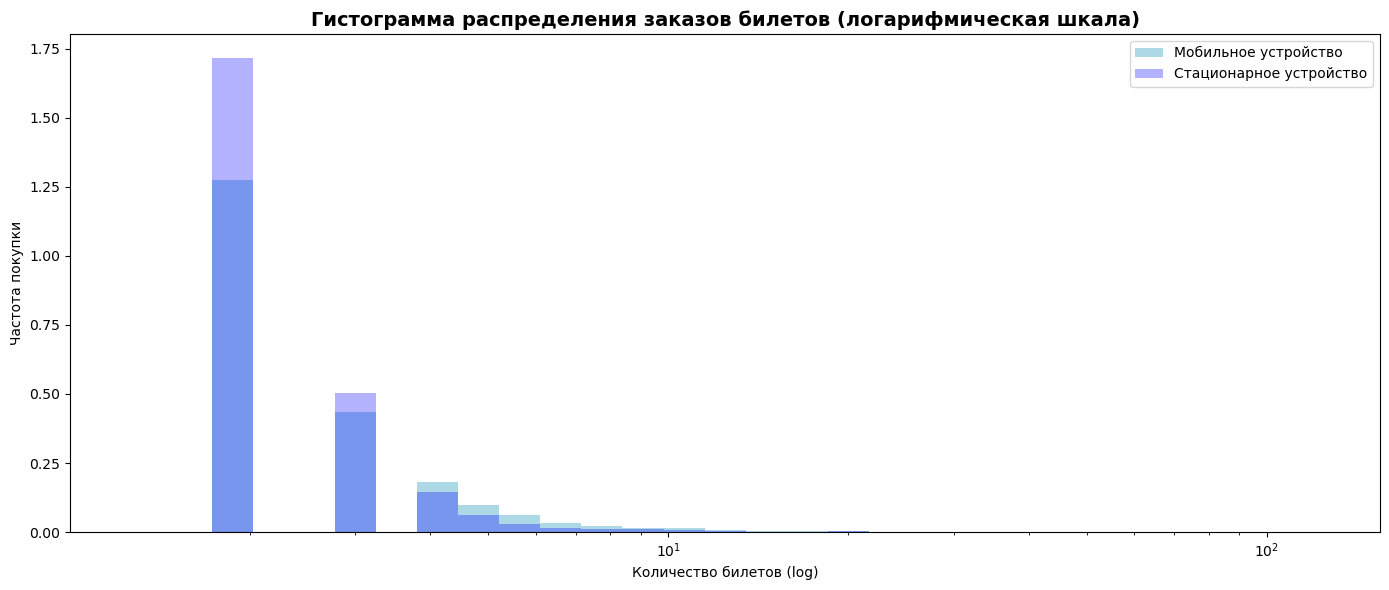

In [61]:
colors=['lightblue', 'blue']

plt.figure(figsize=(14, 6))

max_val=max(mobile_filtered.max(), desktop_filtered.max())
bins=np.logspace(0.1, np.log10(max_val), 30)  # 0.1 чтобы избежать log(0)

plt.hist(mobile_filtered, bins=bins, color=colors[0], label='Мобильное устройство', density=True)
plt.hist(desktop_filtered, bins=bins, alpha=0.3, color=colors[1], label='Стационарное устройство', density=True)

plt.xscale('log')
plt.title('Гистограмма распределения заказов билетов (логарифмическая шкала)', fontsize=14, fontweight='bold')
plt.xlabel('Количество билетов (log)')
plt.ylabel('Частота покупки')
plt.legend()
plt.tight_layout()
plt.show()

Статистика полностью согласуется с гистограммой. Распределение заказов для обеих групп устройств корректно отображено: доминируют пользователи с малым числом заказов, а «тяжёлые» пользователи (с большим числом заказов) образуют редкий «хвост». Различия между мобильными устройствами и стационарными (среднее, медиана, размах) чётко видны как в числах, так и на визуализации.

Остановимся на t-тесте Уэлча.

Установим уровень значимости alpha=0.05.

In [62]:
alpha=0.05

t_stat, p_value=ttest_ind(
    mobile_filtered,           
    desktop_filtered,        
    equal_var=False,     
    alternative='greater' 
)
print(f'p-value: {p_value:}')

if p_value>alpha:
    print('Нулевая гипотеза находит подтверждение! Нет статистически значимых доказательств того, что среднее количество заказов на одного пользователя мобильного приложения выше, чем на стационарных устройствах')
else:
    print('Нулевая гипотеза не находит подтверждения! Есть статистически значимые доказательства того, что среднее количество заказов на одного пользователя мобильного приложения выше, чем на стационарных устройствах.')

p-value: 5.793910569768289e-25
Нулевая гипотеза не находит подтверждения! Есть статистически значимые доказательства того, что среднее количество заказов на одного пользователя мобильного приложения выше, чем на стационарных устройствах.


Как альтернативный метод можно рассмотреть тест Манна-Уитни.

In [63]:
alpha=0.05

stat_mw, p_value=mannwhitneyu(
    mobile_filtered,
    desktop_filtered,
    alternative='greater'
)

print(f'p-value: {p_value:}')

if p_value>alpha:
    print('Не удалось отвергнуть нулевую гипотезу! Нет статистически значимых доказательств того, что среднее количество заказов на одного пользователя мобильного приложения выше, чем на стационарных устройствах.')
else:
    print('Отклоняем нулевую гипотезу! Есть статистически значимые доказательства того, что среднее количество заказов на одного пользователя мобильного приложения выше, чем на стационарных устройствах.')

p-value: 4.78426964962603e-39
Отклоняем нулевую гипотезу! Есть статистически значимые доказательства того, что среднее количество заказов на одного пользователя мобильного приложения выше, чем на стационарных устройствах.


Анализ данных за осенний период с применением t‑теста Уэлча и теста Манна‑Уитни подтвердил статистически значимое превышение среднего количества заказов на одного пользователя в мобильном приложении по сравнению со стационарными устройствами.

#### 4.2. Проверка Гипотезы 2

Нулевая гипотеза(H₀): 
Среднее время между заказами пользователей мобильного приложения не отличается от среднего времени между заказами пользователей со стационарных устройств.

Альтернативная гипотеза(H₁):
Среднее время между заказами пользователей мобильного приложения выше, чем среднее время между заказами пользователей стационарных устройств.

Отсортируем данные по столбцу `days_since_prev`. Выведем статистические показатели. Напомню, что в данном столбце есть пропущенные значения.

In [64]:
test_device_autumn_prev=test_device_autumn.dropna(subset=['days_since_prev'])
orders_prev_filter=test_device_autumn_prev.groupby(['user_id', 'device_type_canonical'])['days_since_prev'].mean().reset_index()

mobile_filtered_prev=orders_prev_filter[orders_prev_filter['device_type_canonical']=='mobile']['days_since_prev']
desktop_filtered_prev=orders_prev_filter[orders_prev_filter['device_type_canonical']=='desktop']['days_since_prev']

display(mobile_filtered_prev.describe(), desktop_filtered_prev.describe())

count    7052.000000
mean       25.254896
std        30.209984
min         0.000000
25%         2.870536
50%        14.000000
75%        36.000000
max       148.000000
Name: days_since_prev, dtype: float64

count    894.000000
mean      31.357178
std       36.564095
min        0.000000
25%        0.000000
50%       16.000000
75%       53.000000
max      146.000000
Name: days_since_prev, dtype: float64

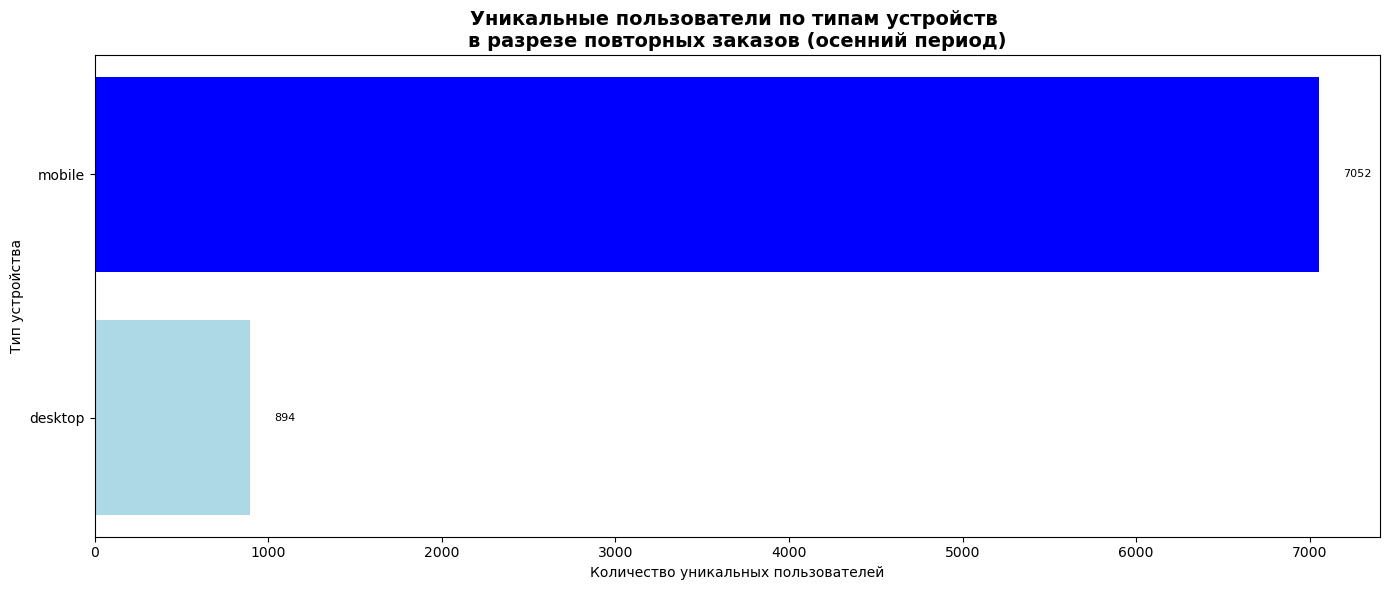

In [65]:
user_counts=orders_prev_filter.groupby('device_type_canonical')['user_id'].nunique()

fig, ax=plt.subplots(figsize=(14, 6))
bars=ax.barh(
    user_counts.index,
    user_counts.values,
    color=['lightblue', 'blue']
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + max(user_counts.values) * 0.02,
        bar.get_y() + bar.get_height() / 2,
        f'{int(width)}',
        ha='left',
        va='center',
        fontsize=8,
    )

ax.set_xlabel('Количество уникальных пользователей')
ax.set_ylabel('Тип устройства')
ax.set_title('Уникальные пользователи по типам устройств \nв разрезе повторных заказов (осенний период)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

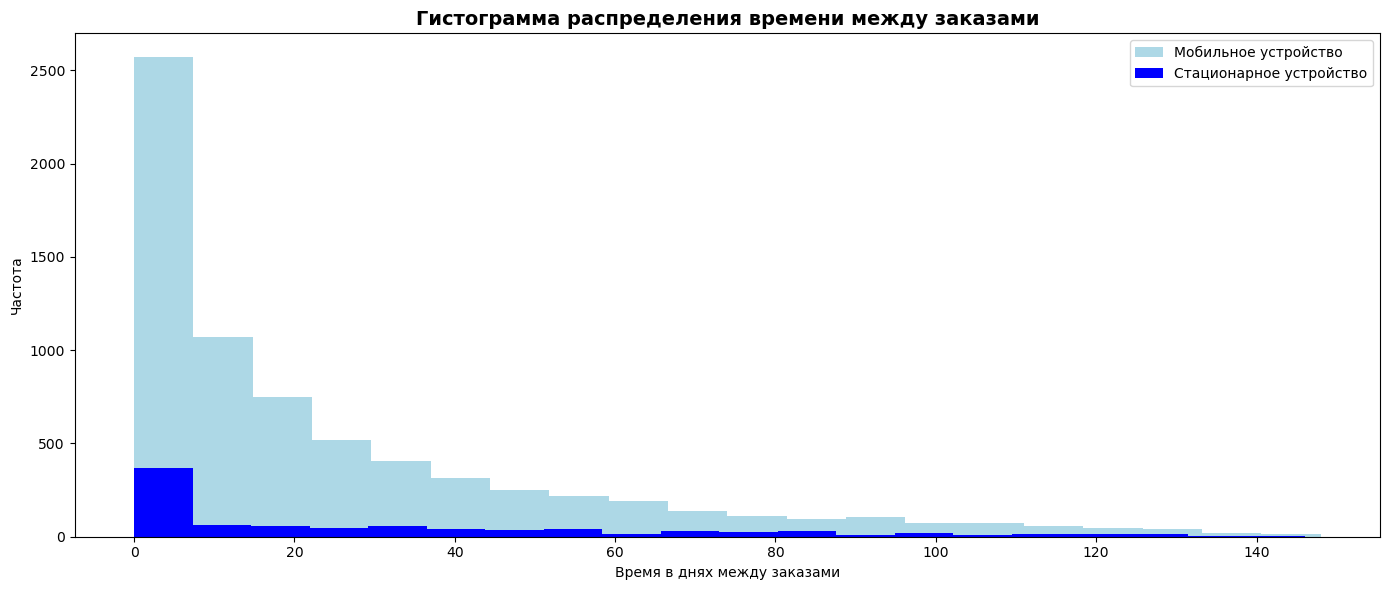

In [66]:
colors=['lightblue', 'blue']

plt.figure(figsize=(14, 6))
plt.hist(mobile_filtered_prev, bins=20, color=colors[0], label='Мобильное устройство')
plt.hist(desktop_filtered_prev, bins=20, color=colors[1], label='Стационарное устройство')
plt.xlabel('Время в днях между заказами')
plt.ylabel('Частота')
plt.title('Гистограмма распределения времени между заказами', fontsize=14, fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()

Снова видим, что выборки имеют экспоненциональное распределение. Наблюдаем большие хвосты. Сделаем сравнительное гистограммное распределение распределения времени между заказами на мобильных устройствах и стационарных устройствах в логарифмическом масштабе, чтобы было более ясно поведение пользователей по типу девайсов.

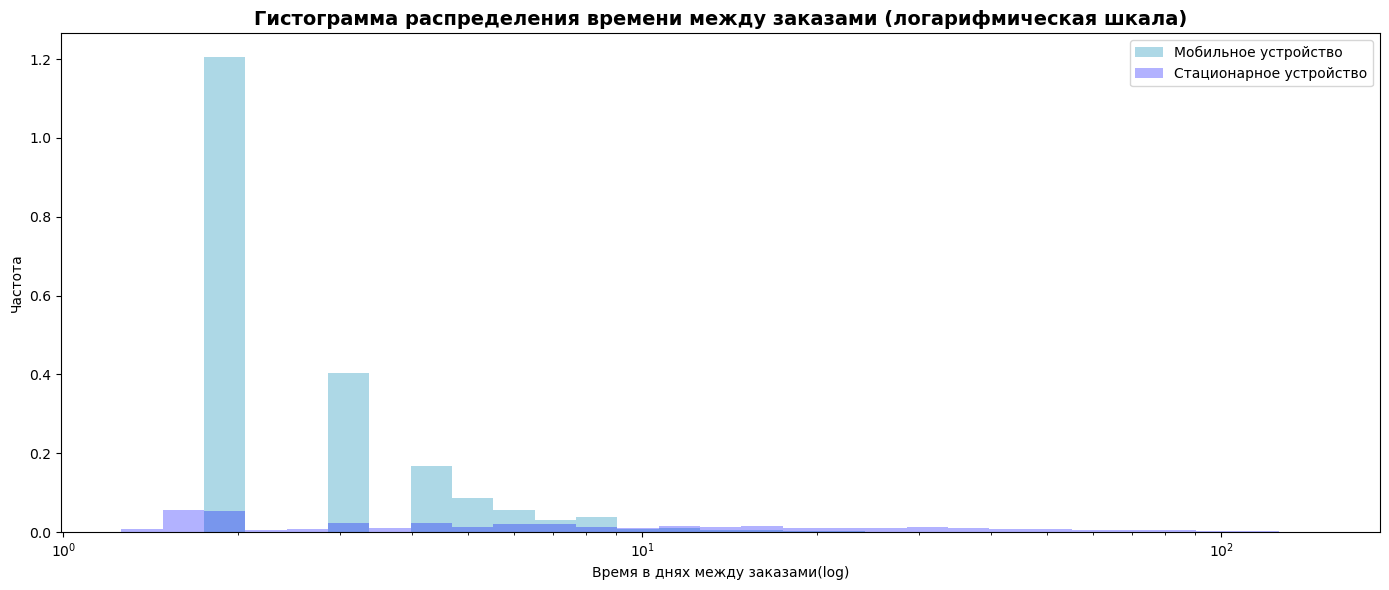

In [67]:
colors=['lightblue', 'blue']

plt.figure(figsize=(14, 6))

max_val=max(mobile_filtered_prev.max(), desktop_filtered.max())
bins=np.logspace(0.1, np.log10(max_val), 30)  # 0.1 чтобы избежать log(0)

plt.hist(mobile_filtered, bins=bins, color=colors[0], label='Мобильное устройство', density=True)
plt.hist(desktop_filtered_prev, bins=bins, alpha=0.3, color=colors[1], label='Стационарное устройство', density=True)

plt.xscale('log')
plt.title('Гистограмма распределения времени между заказами (логарифмическая шкала)', fontsize=14, fontweight='bold')
plt.xlabel('Время в днях между заказами(log)')
plt.ylabel('Частота')
plt.legend()
plt.tight_layout()
plt.show()

Мобильные: более «пиковое» распределение (большинство заказов с интервалом 1–10 дней), что видно и на графике, и в квартилях.
Стационарные: распределение более равномерное, с меньшим «пиком» в коротких интервалах и большей долей средних/длинных промежутков. Логарифмическая шкала подчёркивает, что большинство интервалов коротких (около 1–10 дней), а длинные промежутки (100+ дней) — редкость.

Остановимся на t-тесте Уэлча.

Установим уровень значимости alpha=0.05.

In [68]:
alpha=0.05

t_stat, p_value=ttest_ind(
    mobile_filtered_prev,           
    desktop_filtered_prev,        
    equal_var=False,     
    alternative='greater' 
)
print(f'p-value: {p_value:}')

if p_value>alpha:
    print('Нулевая гипотеза находит подтверждение! Нет статистически значимых доказательств того, что среднее время между заказами пользователей мобильного приложения выше, чем на стационарных устройствах.')
else:
    print('Нулевая гипотеза не находит подтверждения! Есть статистически значимые доказательства того, что среднее время между заказами пользователей мобильного приложения выше, чем на стационарных устройствах.')

p-value: 0.9999990337061575
Нулевая гипотеза находит подтверждение! Нет статистически значимых доказательств того, что среднее время между заказами пользователей мобильного приложения выше, чем на стационарных устройствах.


Анализ данных осеннего периода с использованием t-теста Уэлча не подтвердил гипотезу о том, что среднее время между заказами у пользователей мобильного приложения статистически значимо превышает аналогичный показатель для стационарных устройств.

### 5. Общий вывод и рекомендации

<b>Общий вывод</b>

1. Информация о данных

Анализировались 3 датасета (`final_tickets_orders_df`, `final_tickets_events_df`, `final_tickets_tenge_df`), объединённые в один датафрейм (287 356 строк, 28 столбцов) за период с 10.01.2024 по 31.12.2024. Данные прошли очистку и оптимизацию. Были добавлены новые столбцы для удобства дальнейшего анализа.

2. Основные результаты

Популярные мероприятия осенью: концерты (37%), театр (25%), спорт (11%).

Изменения осенью:
- вырос спрос на театр, спорт и семейные мероприятия (0+); снизился — на концерты и мероприятия для взрослых (18+);
- появились заказы на «ёлки» (1 %).

Средний чек: снизился с ~200 руб. в начале сентября до ~150 руб. в конце октября.

Активность пользователей:
- 80–81 % заказов — с мобильных устройств;
- рост числа заказов и активных пользователей (с ~550 до ~1 300) с сентября по октябрь;
- среднее число заказов на пользователя — 2–3 в день (всплески до 5–6);
- пик активности — вторник и четверг, спад — в выходные (особенно в воскресенье);
- более высокая стоимость чека в выходные.

Лидеры по регионам: Каменевский регион (31%), Североярская область (15%), Широковская область (6%).

Лидеры среди партнёров: «Билеты без проблем» (22% заказов, 16% выручки), «Мой билет» (15% выручки), «Облачко» (12% выручки).

Регионы с потенциалом: Медовская область, Озернинский край (спрос > предложения).

Регионы с избытком предложения: Светополянский округ, Речиновская область.

3. Результаты проверки гипотез

Гипотеза 1 - подтверждено: среднее количество заказов на пользователя выше в мобильном приложении (t‑тест Уэлча и тест Манна‑Уитни).

Гипотеза 2 - не подтверждено: среднее время между заказами у мобильных пользователей не превышает показатель стационарных устройств (t‑тест Уэлча).

<b>Рекомендации</b>

Сезонность: учитывать осеннее снижение цен, планировать акции в периоды падения среднего чека.

Регионы:
- в Медовской области и Озернинском крае — наращивать предложение;
- в Светополянском округе и Речиновской области — анализировать причины низкого спроса.

Партнёры:
- «Лови билет!» — повысить конверсию заказов через маркетинг;
- стабильным игрокам («Билеты в руки», «Лучшие билеты») — искать точки роста выручки.

Промоакции: запускать во вторник и четверг (пик активности), изучить причины высокого чека в выходные для адаптации ценовой политики.

Мобильное приложение: улучшать скорость работы (80–81 % заказов), персонализировать предложения.

Мероприятия:
- продвигать театр, спорт, семейные события осенью;
- анализировать снижение интереса к концертам и взрослым мероприятиям.

Всплески активности: изучить причины всплесков (>5–6 заказов на пользователя) и тиражировать успешные практики.

Ценовая политика: протестировать дифференцированные цены по дням недели и типам мероприятий, оценить связь цены и спроса.